# Análise de Dados SCADA — EDP Open Data 2017

## Objetivo
Este notebook analisa dados SCADA de turbinas eólicas reais fornecidos pela EDP (Energias de Portugal).
O foco é diagnóstico de desempenho, análise de yaw error, detecção de anomalias e correlação com eventos de falha.

## Fonte dos Dados
- **Plataforma:** EDP Open Data (opendata.edp.com)
- **Período:** 2017 (resolução 10 minutos)
- **Turbinas analisadas:** T01, T06, T07, T11

## Variáveis SCADA Disponíveis
| Variável | Coluna Canônica | Unidade | Descrição |
|---|---|---|---|
| `Amb_WindSpeed_Avg` | `wind_speed_ms` | m/s | Velocidade média do vento |
| `Pwr_Avg` | `power_kw` | kW | Potência ativa média |
| `Nac_Direction_Avg` | `nac_direction_deg` | ° | Direção da nacele |
| `Amb_WindDir_Abs_Avg` | `wind_direction_deg` | ° | Direção absoluta do vento |
| `Timestamp` | `timestamp` | — | Marca temporal (UTC) |
| `Turbine_ID` | `turbine` | — | Identificador da turbina |


## Detecção de Anomalias SCADA com DBSCAN

**DBSCAN** é utilizado aqui para detectar comportamentos anômalos na curva de potência das turbinas.

### Motivação para dados SCADA
Em dados SCADA reais:
- A curva de potência empírica tem formato S (cut-in → rated → cut-out)
- Pontos **abaixo** da curva típica podem indicar: parada parcial, píretching adaptativo, degradação aerodinâmica
- Pontos **fora** da nuvem principal são anomalias que merecem investigação

### Parâmetros
| Parâmetro | Valor | Justificativa |
|---|---|---|
| `eps` | 0.3 | Raio em espaço normalizado — detecta outliers que estão ≥ 30% de desvio da nuvem principal |
| `min_samples` | 10 | Requer ao menos 10 vizinhos para considerar operação "normal" |

### Resultado esperado
- **Label ≥ 0:** Operação normal (dentro de um cluster bem formado)
- **Label = -1:** Anomalia — ponto isolado fora das regiões de alta densidade


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

TURBINES = ['T01', 'T06', 'T07', 'T11']


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# FUNÇÕES AUXILIARES — Reutilizáveis em todo o notebook
# ═══════════════════════════════════════════════════════════════════════════

def yaw_error(df):
    """Calcula yaw error circular no intervalo [-180, 180] graus."""
    return (df['Nac_Direction_Avg'] - df['Amb_WindDir_Abs_Avg'] + 180) % 360 - 180


def plot_yaw_histogram(df_turbine, turbine_id, ax=None):
    """Plota histograma de yaw error com limites operacionais em ±15 graus."""
    df_plot = df_turbine.copy()
    df_plot['yaw_err'] = yaw_error(df_plot)

    created_fig = False
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))
        created_fig = True

    yaw_values = df_plot['yaw_err'].dropna()
    median_err = yaw_values.median()
    std_err = yaw_values.std()

    ax.hist(yaw_values, bins=72, edgecolor='white', color='steelblue', alpha=0.8)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.8, label='0° (alinhamento perfeito)')
    ax.axvline(x=median_err, color='orange', linestyle='-', linewidth=2, alpha=0.8,
               label=f'Mediana = {median_err:.1f}°')
    ax.axvline(x=-15, color='darkgreen', linestyle=':', linewidth=1.5, alpha=0.8)
    ax.axvline(x=15, color='darkgreen', linestyle=':', linewidth=1.5, alpha=0.8, label='Limites ±15°')

    ax.set_title(
        f'Turbina {turbine_id} — Yaw Error (Nac_Dir - WindDir)\n'
        f'Mediana = {median_err:.1f}° | Std = {std_err:.1f}°',
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel('Yaw Error (°)')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=10)

    if created_fig:
        plt.tight_layout()
        plt.show()

    return median_err, std_err


def plot_power_curve_scatter(df_turbine, turbine_id, ax=None):
    """Scatter plot velocidade × potência por turbina, com e sem outliers."""
    clean = df_turbine[df_turbine['outlier_flag'] == 0]
    outliers = df_turbine[df_turbine['outlier_flag'] == 1]

    created_fig = False
    if ax is None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        created_fig = True
    else:
        axes = ax
        fig = None

    ax1, ax2 = axes
    if fig is not None:
        fig.suptitle(f'Turbina {turbine_id} — Curva de Potência', fontsize=15, fontweight='bold')

    ax1.scatter(clean['Amb_WindSpeed_Avg'], clean['Grd_Prod_Pwr_Avg'],
                alpha=0.3, s=5, c='steelblue', label='Dados limpos')
    ax1.set_title('Sem Outliers')
    ax1.set_xlabel('Velocidade do Vento (m/s)')
    ax1.set_ylabel('Potência (kW)')
    ax1.legend(markerscale=5)

    ax2.scatter(clean['Amb_WindSpeed_Avg'], clean['Grd_Prod_Pwr_Avg'],
                alpha=0.3, s=5, c='steelblue', label='Limpos')
    ax2.scatter(outliers['Amb_WindSpeed_Avg'], outliers['Grd_Prod_Pwr_Avg'],
                alpha=0.3, s=5, c='red', label='Outliers')
    ax2.set_title('Com Outliers Destacados')
    ax2.set_xlabel('Velocidade do Vento (m/s)')
    ax2.set_ylabel('Potência (kW)')
    ax2.legend(markerscale=5)

    if created_fig:
        plt.tight_layout()
        plt.show()

    return clean, outliers


def plot_wind_rose_by_turbine(df, turbine_id, ax=None):
    """Rosa dos ventos (potência média por direção) para uma turbina específica."""
    if 'Turbine_ID' in df.columns:
        df_t = df[df['Turbine_ID'] == turbine_id].copy()
    else:
        df_t = df.copy()

    n_sectors = 16
    sector_width = 360 / n_sectors
    dir_labels = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
                  'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']

    df_t['wind_sector'] = df_t['Amb_WindDir_Abs_Avg'].apply(
        lambda x: int(((x + sector_width / 2) % 360) // sector_width) if pd.notna(x) else np.nan
    )

    pwr_by_sector = df_t.groupby('wind_sector')['Grd_Prod_Pwr_Avg'].mean()
    pwr_by_sector = pwr_by_sector.reindex(range(n_sectors), fill_value=0)

    angles = np.radians(np.arange(0, 360, sector_width))
    bar_width = np.radians(sector_width) * 0.9

    created_fig = False
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
        created_fig = True

    norm = plt.Normalize(vmin=pwr_by_sector.values.min(), vmax=pwr_by_sector.values.max())
    colors = plt.cm.YlOrRd(norm(pwr_by_sector.values))

    ax.bar(angles, pwr_by_sector.values, width=bar_width, alpha=0.8,
           color=colors, edgecolor='white', linewidth=0.5)

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.arange(0, 360, sector_width), dir_labels, fontsize=9)
    ax.set_title(f'Rosa dos Ventos — Turbina {turbine_id}', fontsize=12, fontweight='bold', pad=20)

    if created_fig:
        sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.1)
        cbar.set_label('Potência média (kW)', fontsize=10)
        plt.tight_layout()
        plt.show()

    return pwr_by_sector


def run_dbscan_analysis(df_turbine, x_col='wind_speed_ms', y_col='power_kw', eps=0.3, min_samples=10):
    """Executa DBSCAN com parâmetros padrão e retorna labels alinhados ao índice."""
    labels_series = pd.Series(index=df_turbine.index, dtype='float64')

    required_cols = [x_col, y_col]
    valid = df_turbine[required_cols].dropna()
    if valid.empty:
        return labels_series

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(valid[[x_col, y_col]])

    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)

    labels_series.loc[valid.index] = labels
    return labels_series


print('Funções auxiliares carregadas: yaw_error, plot_yaw_histogram, plot_power_curve_scatter, plot_wind_rose_by_turbine, run_dbscan_analysis')

Funções auxiliares carregadas: yaw_error, plot_yaw_histogram, plot_power_curve_scatter, plot_wind_rose_by_turbine, run_dbscan_analysis


## Fusão Temporal com `pd.merge_asof` — Tolerância de 10 Minutos

Para correlacionar dados SCADA com eventos de falha, é necessário unir dois DataFrames com timestamps diferentes.

### Por que `merge_asof`?
- Dados SCADA têm resolução de **10 minutos**
- Registros de falha têm timestamps exatos (podem não coincidir com o timestamp SCADA mais próximo)
- `merge_asof` realiza um **left join por proximidade temporal** — para cada registro SCADA, busca o evento de falha mais próximo dentro de uma tolerância

### Tolerância de 10 minutos
A tolerância (`tolerance=pd.Timedelta("10min")`) garante que apenas eventos próximos no tempo sejam associados,
evitando falsos positivos de correspondência entre eventos distantes.

```python
pd.merge_asof(df_scada.sort_values("timestamp"),
              df_failures.sort_values("failure_timestamp"),
              left_on="timestamp",
              right_on="failure_timestamp",
              tolerance=pd.Timedelta("10min"),
              direction="nearest")
```


In [3]:

df_all = pd.read_csv('Wind_Turbine_SCADA_tratado_consolidado.csv', parse_dates=['Timestamp'])

df_metmast = pd.read_csv('Onsite_MetMast_SCADA_tratado.csv', parse_dates=['Timestamp'])

df_failures = pd.read_csv('opendata-wind-failures-2017 (3).csv', sep=';', parse_dates=['Timestamp'])
df_failures = df_failures.rename(columns={'Component': 'Failure_Component', 'Remarks': 'Failure_Remarks'})
print(f"Falhas carregadas: {df_failures.shape[0]} registros")
print(df_failures.head())

turbines = {tid: df_all[df_all['Turbine_ID'] == tid].copy() for tid in TURBINES}

TOLERANCE = pd.Timedelta('10min')
for tid in TURBINES:
    failures_tid = df_failures[df_failures['Turbine_ID'] == tid][['Timestamp', 'Failure_Component', 'Failure_Remarks']].sort_values('Timestamp')

    turbines[tid] = turbines[tid].sort_values('Timestamp')
    turbines[tid] = pd.merge_asof(
        turbines[tid],
        failures_tid,
        on='Timestamp',
        tolerance=TOLERANCE,
        direction='nearest'
    )
    df_t = turbines[tid]
    n_failures = df_t['Failure_Component'].notna().sum()
    print(f"  {tid}: {len(df_t)} registros | {n_failures} com falha registrada (tolerância={TOLERANCE})")

print(f"\ndf_all shape: {df_all.shape}")
print(f"df_metmast shape: {df_metmast.shape}")
print("Registros por turbina (após merge com falhas):")
for tid, df_t in turbines.items():
    print(f"  {tid}: {df_t.shape[0]} registros")

print(f"\nTurbinas disponíveis: {df_all['Turbine_ID'].unique()}")


Falhas carregadas: 12 registros
  Turbine_ID  Failure_Component                 Timestamp  \
0        T01        TRANSFORMER 2017-08-11 13:14:00+00:00   
1        T06            GEARBOX 2017-10-17 08:38:00+00:00   
2        T06    HYDRAULIC_GROUP 2017-08-19 09:47:00+00:00   
3        T07  GENERATOR_BEARING 2017-08-20 06:08:00+00:00   
4        T07          GENERATOR 2017-08-21 14:47:00+00:00   

              Failure_Remarks  
0     Transformer fan damaged  
1    Gearbox bearings damaged  
2          Oil leakage in Hub  
3  Generator bearings damaged  
4           Generator damaged  
  T01: 52244 registros | 1 com falha registrada (tolerância=0 days 00:10:00)
  T06: 52346 registros | 3 com falha registrada (tolerância=0 days 00:10:00)
  T07: 52294 registros | 8 com falha registrada (tolerância=0 days 00:10:00)
  T11: 52352 registros | 5 com falha registrada (tolerância=0 days 00:10:00)

df_all shape: (209236, 84)
df_metmast shape: (34831, 42)
Registros por turbina (após merge com falha

In [4]:
# Célula 3 — Verificação de funções auxiliares

print('Função yaw_error() já definida na seção FUNÇÕES AUXILIARES.')

Função yaw_error() já definida na seção FUNÇÕES AUXILIARES.


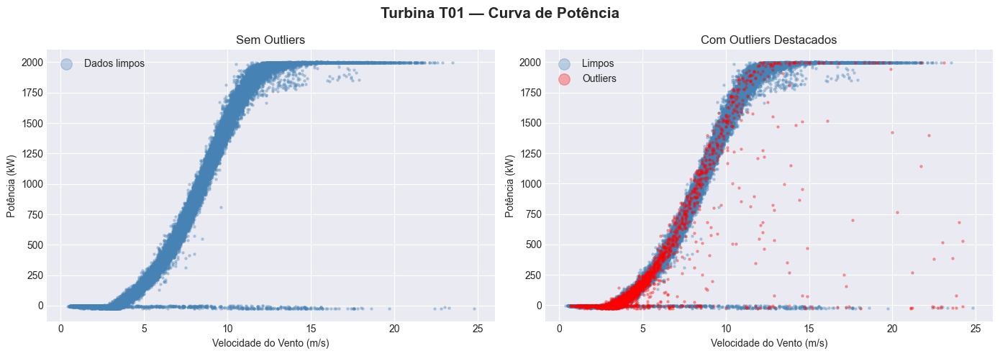

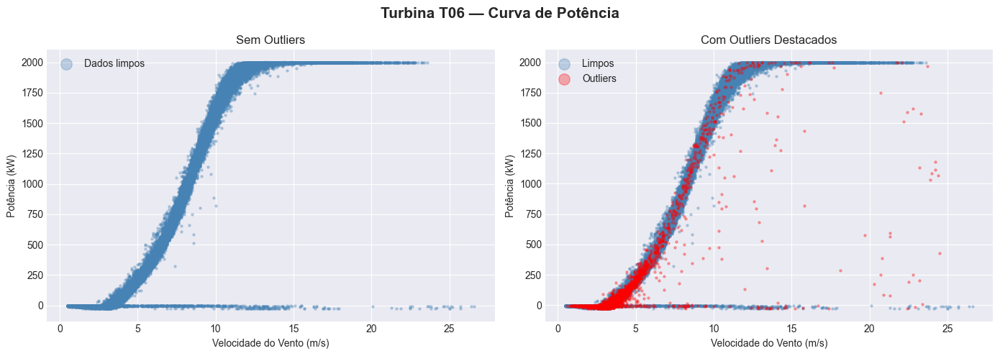

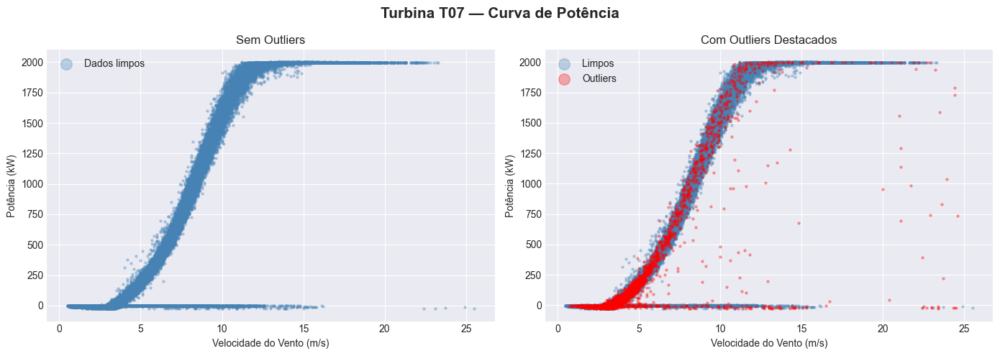

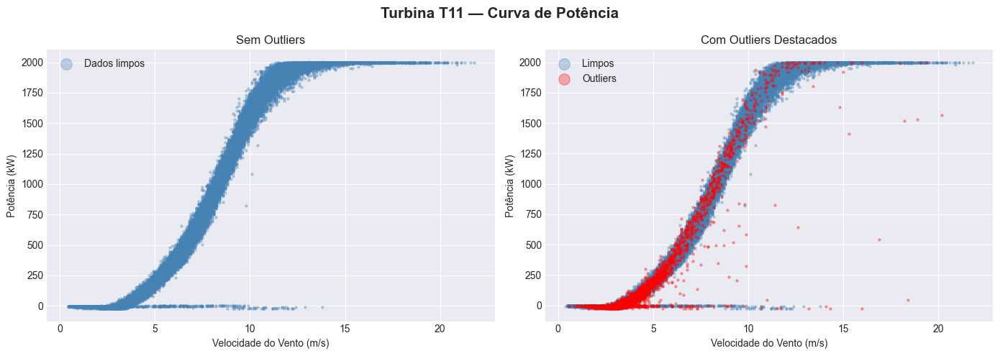

In [5]:
for tid in TURBINES:
    _ = plot_power_curve_scatter(turbines[tid], tid)

A curva de potência é a relação fundamental da turbina eólica: mapeia a velocidade do vento (`Amb_WindSpeed_Avg`) para a potência gerada (`Grd_Prod_Pwr_Avg`). O gráfico da esquerda mostra apenas os dados limpos; o da direita sobrepõe os outliers em vermelho.

**Informações obtidas:**
- **Formato sigmoidal esperado:** A curva limpa deve apresentar: (1) potência zero abaixo do cut-in (~3–4 m/s), (2) crescimento cúbico (P ∝ v³) na região parcial e (3) platô na potência nominal (~12–13 m/s) até o cut-out.
- **Eficácia da filtragem de outliers:** Comparando os dois painéis, avalia-se se os outliers removidos eram realmente dados espúrios (pontos claramente fora da envelope esperada) ou dados legítimos em condições atípicas.
- **Dispersão na região cúbica:** Alta dispersão na zona intermediária (5–12 m/s) pode indicar turbulência elevada, yaw misalignment, variações de densidade do ar ou icing nas pás.
- **Underperformance:** Pontos significativamente abaixo da curva ideal na região de operação normal indicam perdas — seja por curtailment, degradação mecânica ou problemas de controle.
- **Comparação entre turbinas:** Diferenças na curva de potência entre turbinas do mesmo modelo e site revelam disparidades de performance que podem direcionar manutenção prioritária.

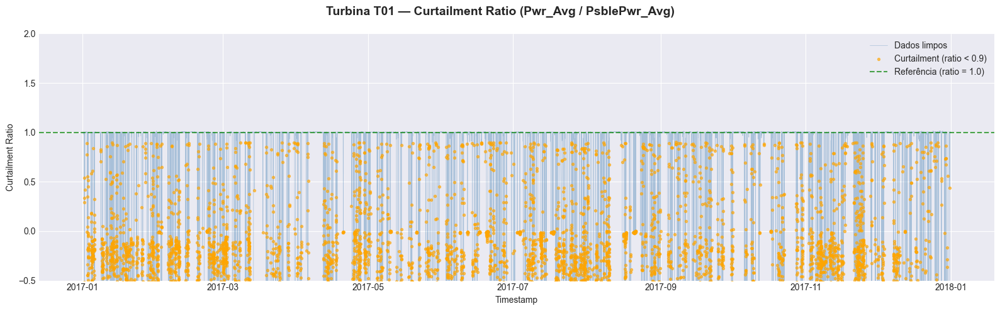

  T01: 16.9% dos registros limpos com curtailment (ratio < 0.9)



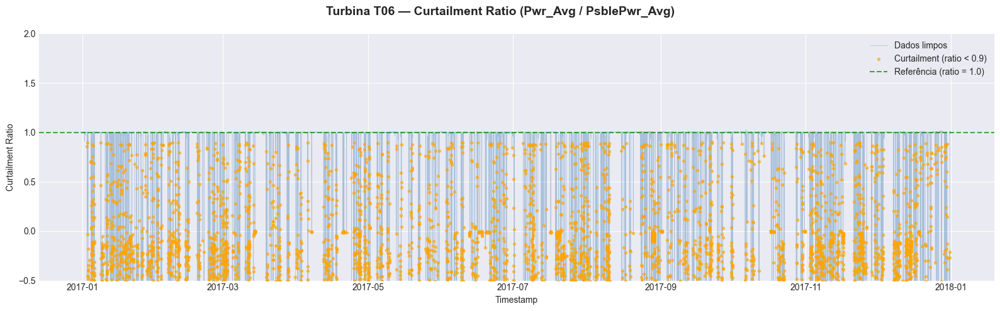

  T06: 16.7% dos registros limpos com curtailment (ratio < 0.9)



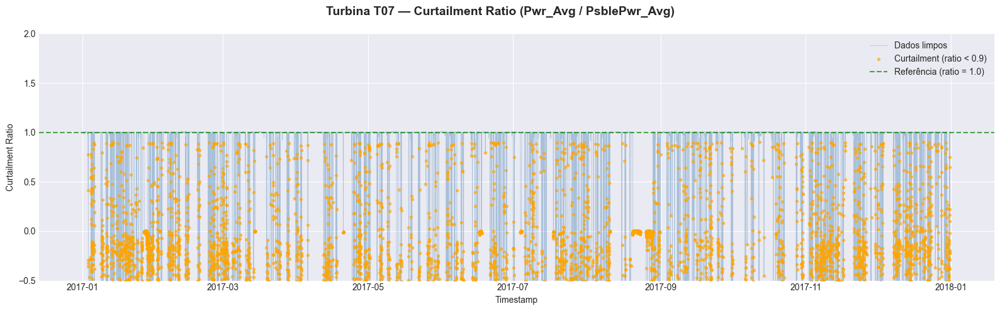

  T07: 19.0% dos registros limpos com curtailment (ratio < 0.9)



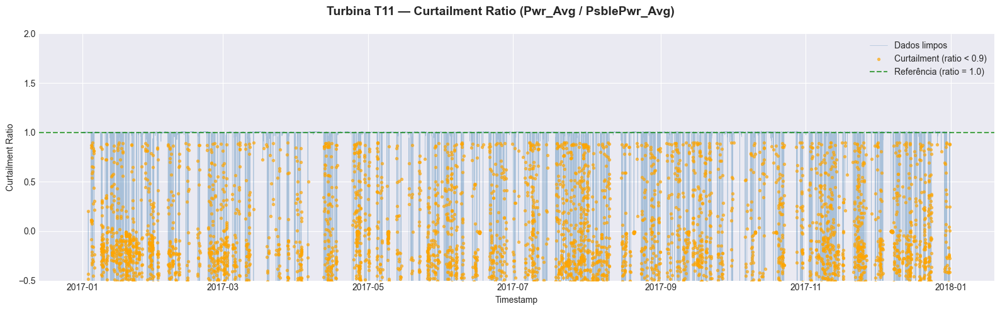

  T11: 16.5% dos registros limpos com curtailment (ratio < 0.9)



In [6]:

for tid in TURBINES:
    df_t = turbines[tid].copy()
    df_t = df_t.sort_values('Timestamp')

    # Calcular curtailment ratio
    df_t['curtailment_ratio'] = df_t['Grd_Prod_Pwr_Avg'] / df_t['Grd_Prod_PsblePwr_Avg'].replace(0, np.nan)

    clean = df_t[df_t['outlier_flag'] == 0]
    curtailed = clean[clean['curtailment_ratio'] < 0.9]

    fig, ax = plt.subplots(figsize=(16, 5))
    fig.suptitle(f'Turbina {tid} — Curtailment Ratio (Pwr_Avg / PsblePwr_Avg)', fontsize=14, fontweight='bold')

    ax.plot(clean['Timestamp'], clean['curtailment_ratio'],
            alpha=0.4, linewidth=0.5, color='steelblue', label='Dados limpos')
    ax.scatter(curtailed['Timestamp'], curtailed['curtailment_ratio'],
               alpha=0.6, s=8, color='orange', label='Curtailment (ratio < 0.9)', zorder=3)
    ax.axhline(y=1.0, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Referência (ratio = 1.0)')

    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Curtailment Ratio')
    ax.legend(fontsize=10)
    ax.set_ylim(-0.5, 2.0)
    plt.tight_layout()
    plt.show()

    pct_curtailed = len(curtailed) / max(len(clean), 1) * 100
    print(f"  {tid}: {pct_curtailed:.1f}% dos registros limpos com curtailment (ratio < 0.9)\n")

A série temporal do curtailment ratio (`Pwr_Avg / PsblePwr_Avg`) compara a potência efetivamente gerada com a potência possível (que a turbina poderia gerar dado o vento disponível). Valores < 1.0 indicam que a turbina está operando abaixo do seu potencial; valores < 0.9 são destacados como curtailment.

**Informações obtidas:**
- **Presença e frequência de curtailment:** A porcentagem de registros com ratio < 0.9 quantifica quanto a turbina foi limitada. Curtailment pode ser imposto por: restrições da rede (limite de exportação), controle de ruído (noise-reduced operation), restrições ambientais (proteção de fauna), ou condições de subtensão/sobretensão na rede.
- **Padrões temporais:** Curtailment concentrado em horários específicos (ex: noite) sugere limitação por ruído. Se concentrado em períodos de vento forte, sugere limitação pela capacidade da rede (grid constraint).
- **Referência (ratio = 1.0, linha verde):** Registros acima de 1.0 são raros e indicam que a potência gerada superou a estimativa de potência possível — tipicamente por erros na estimação do PsblePwr ou por recuperação de energia acumulada.
- **Financeiro:** Cada ponto-percentual de curtailment representa energia perdida (e receita perdida). Essa métrica é fundamental para negociações com o operador da rede e para estudos de viabilidade de armazenamento.

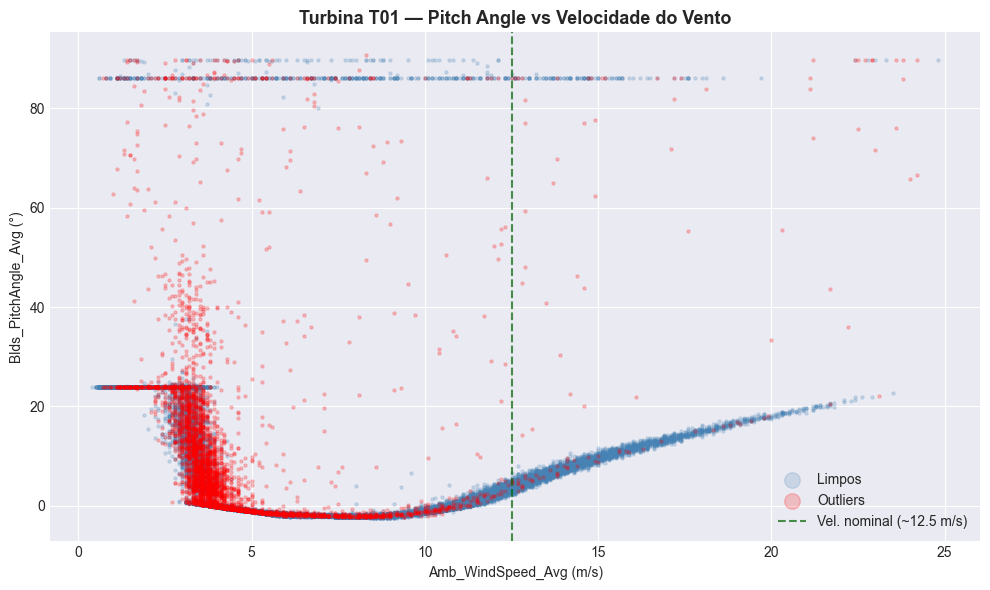

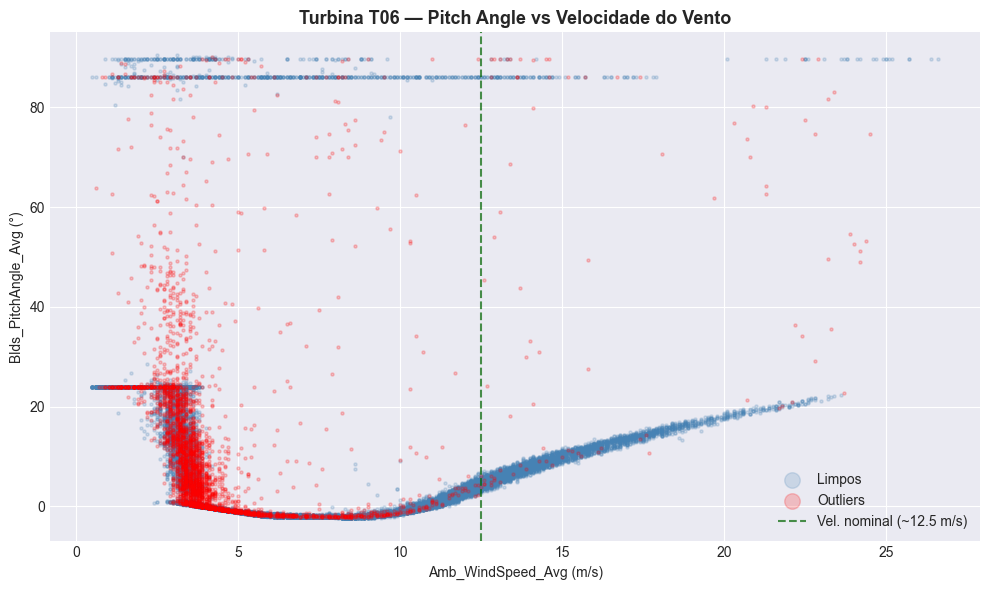

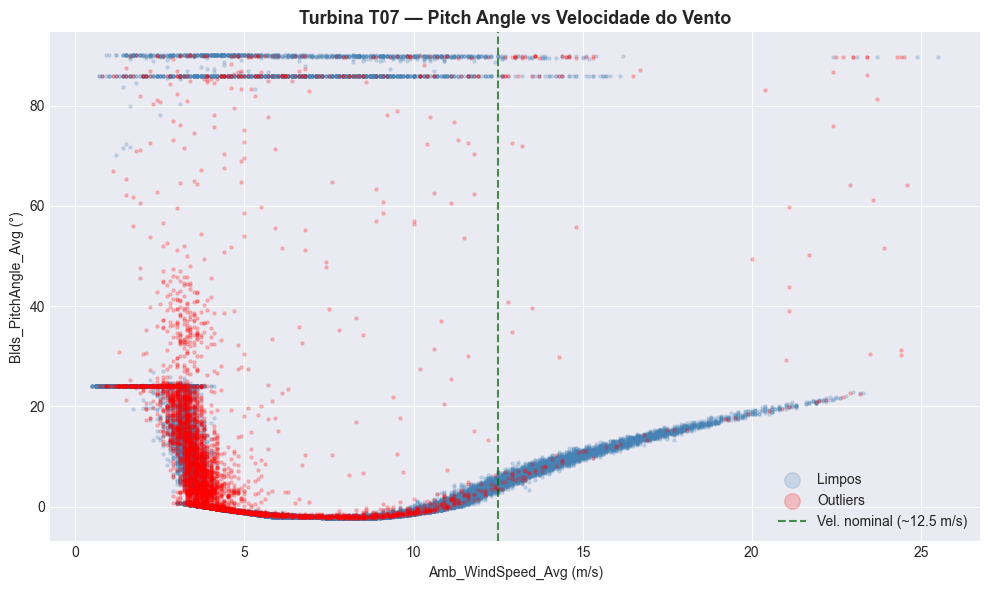

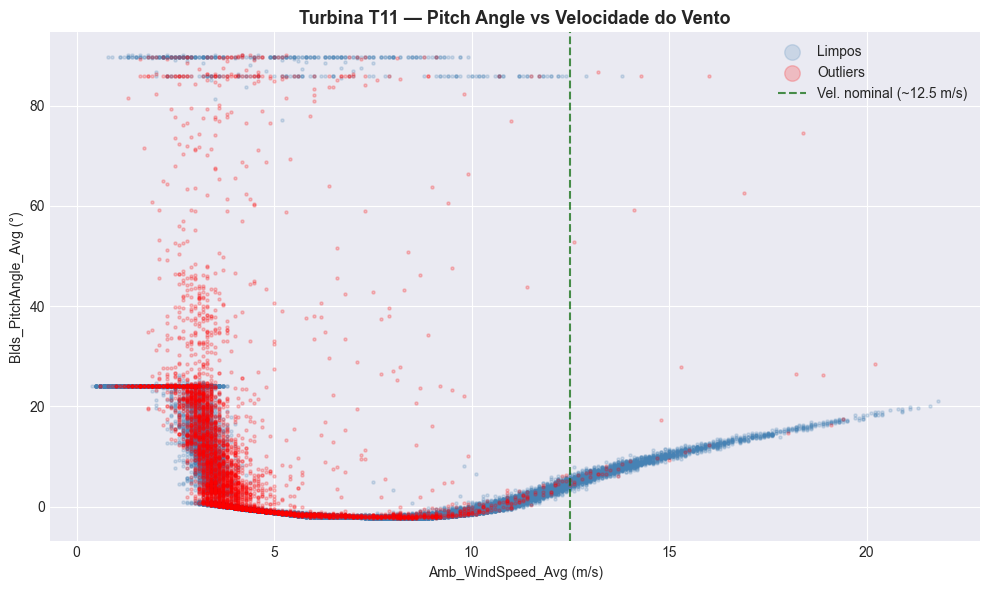

In [7]:
for tid in TURBINES:
    df_t = turbines[tid]
    clean = df_t[df_t['outlier_flag'] == 0]
    outliers = df_t[df_t['outlier_flag'] == 1]

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(clean['Amb_WindSpeed_Avg'], clean['Blds_PitchAngle_Avg'],
               alpha=0.2, s=5, c='steelblue', label='Limpos')
    ax.scatter(outliers['Amb_WindSpeed_Avg'], outliers['Blds_PitchAngle_Avg'],
               alpha=0.2, s=5, c='red', label='Outliers')

    ax.axvline(x=12.5, color='darkgreen', linestyle='--', linewidth=1.5,
               alpha=0.7, label='Vel. nominal (~12.5 m/s)')

    ax.set_title(f'Turbina {tid} — Pitch Angle vs Velocidade do Vento', fontsize=13, fontweight='bold')
    ax.set_xlabel('Amb_WindSpeed_Avg (m/s)')
    ax.set_ylabel('Blds_PitchAngle_Avg (°)')
    ax.legend(markerscale=5, fontsize=10)
    plt.tight_layout()
    plt.show()


O scatter plot relaciona a velocidade do vento com o ângulo de pitch (inclinação das pás) para cada turbina, separando dados limpos de outliers. A linha vertical tracejada marca a velocidade nominal (~12.5 m/s).

**Informações obtidas:**
- **Região de pitch zero (v < nominal):** Abaixo da velocidade nominal, o pitch deve permanecer em ~0° (pás totalmente expostas ao vento) para maximizar a captura de energia. Valores diferentes de 0° nessa região indicam curtailment, controle de ruído ou proteção por excesso de turbulência.
- **Região de pitch ativo (v > nominal):** Acima da velocidade nominal, as pás são giradas progressivamente (feathering) para limitar a potência à capacidade nominal do gerador. Uma relação suave e crescente é esperada.
- **Outliers vermelhos:** Pontos com pitch anômalo para uma dada velocidade de vento podem indicar falha no sistema de pitch (atuador hidráulico ou elétrico), erros de sensor, ou momentos de parada/partida da turbina.
- **Comparação entre turbinas:** Diferenças no perfil pitch–vento entre turbinas do mesmo modelo indicam calibrações diferentes do controlador ou degradação diferencial do sistema de pitch.
- **Utilidade prática:** O comportamento do pitch é crucial para a eficiência e segurança da turbina. Anomalias neste gráfico frequentemente precedem falhas mecânicas no sistema de pás.

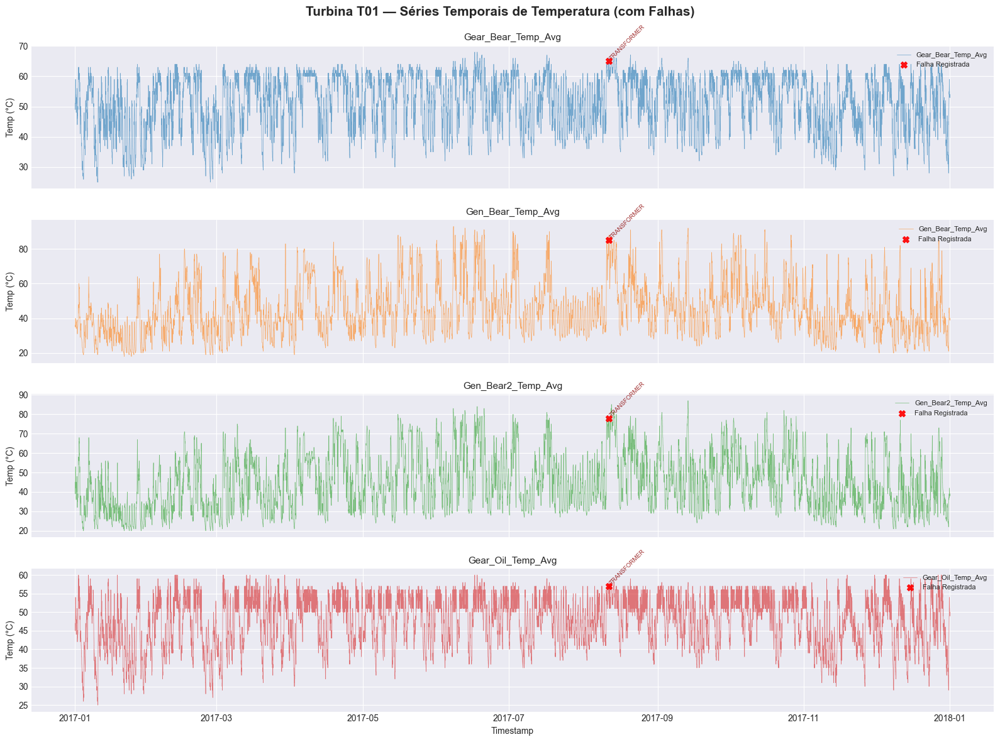

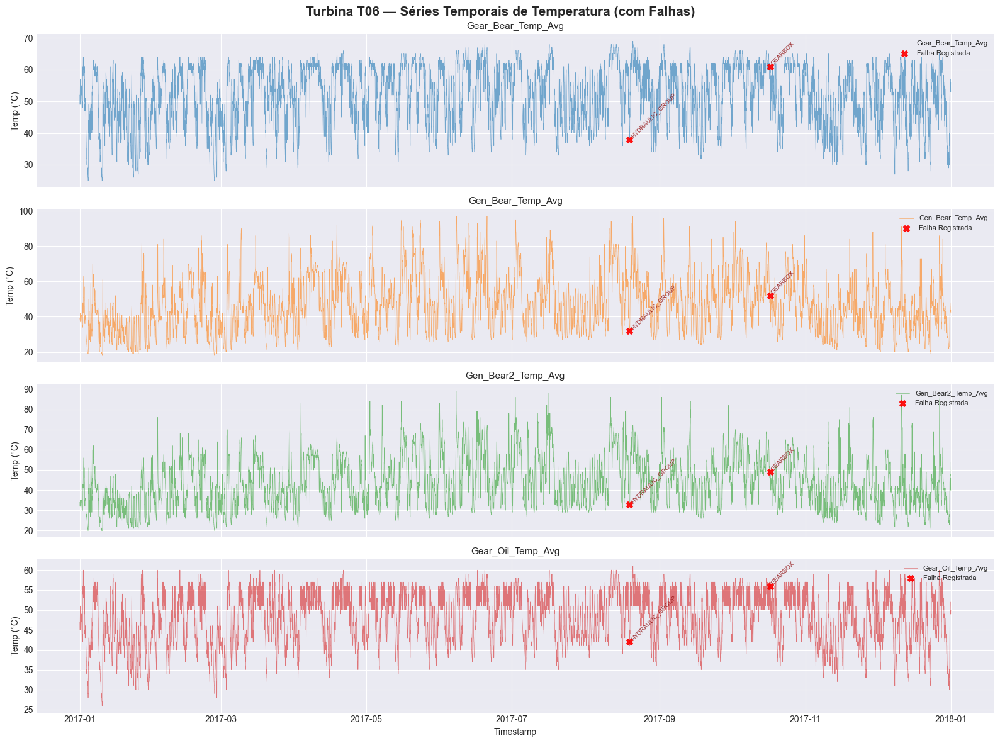

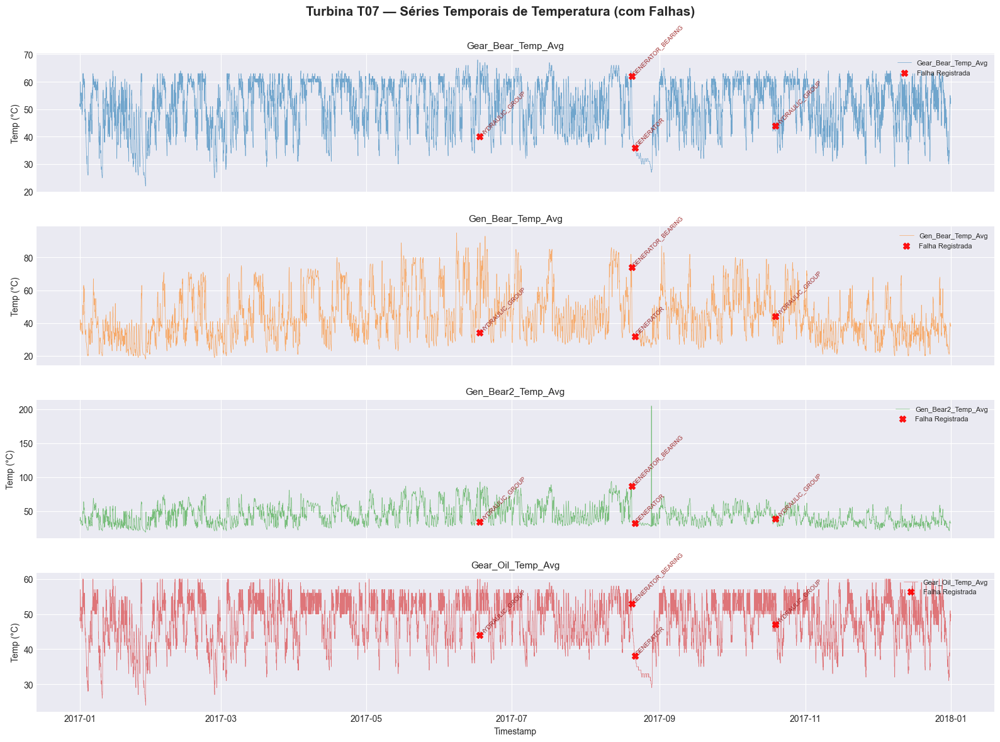

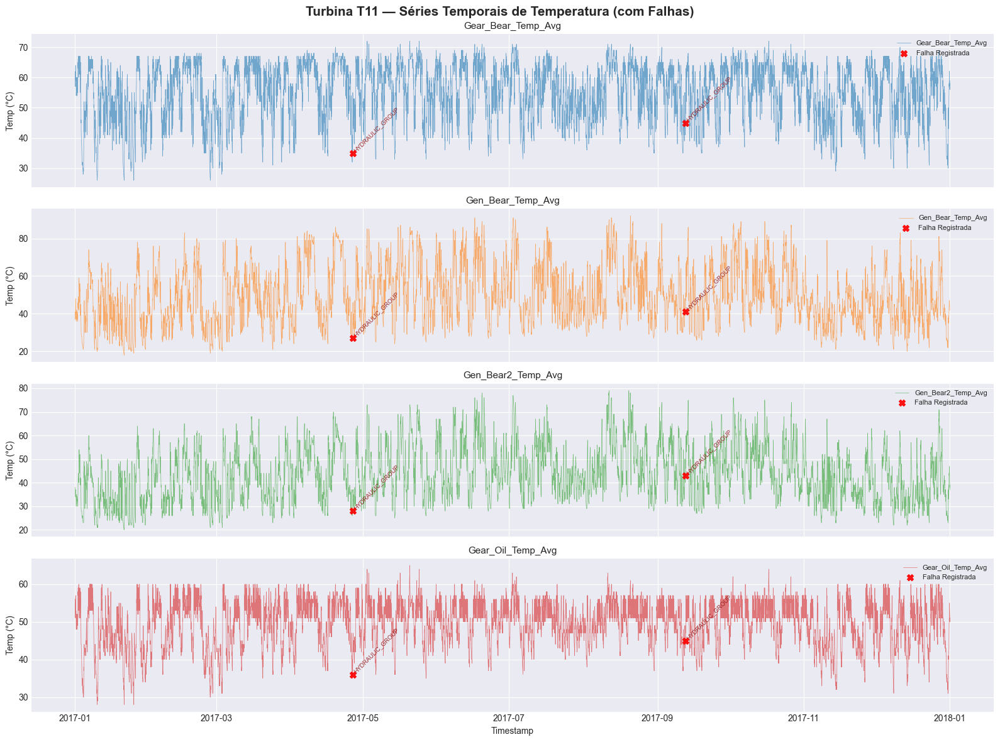

In [8]:

# Célula 4E — Séries Temporais de Temperatura com Destaque de Falhas (por Turbina)

temp_cols = ['Gear_Bear_Temp_Avg', 'Gen_Bear_Temp_Avg', 'Gen_Bear2_Temp_Avg', 'Gear_Oil_Temp_Avg']
temp_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for tid in TURBINES:
    df_t = turbines[tid].sort_values('Timestamp')

    # Deduplicar eventos de falha: o merge_asof pode associar múltiplos registros
    # SCADA consecutivos (dentro de 10min) à mesma falha. Mantemos apenas o primeiro
    # registro de cada grupo de ocorrências próximas (< 1h) do mesmo componente+remarks.
    # Falhas genuinamente distintas do mesmo componente (separadas por horas/dias) são preservadas.
    _fp = df_t[df_t['Failure_Component'].notna()].copy().sort_values('Timestamp')
    _fp['_tdiff'] = _fp.groupby(['Failure_Component', 'Failure_Remarks'])['Timestamp'].diff()
    failure_pts = _fp[
        _fp['_tdiff'].isna() | (_fp['_tdiff'] > pd.Timedelta('1h'))
    ].drop(columns=['_tdiff'])

    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
    fig.suptitle(f'Turbina {tid} — Séries Temporais de Temperatura (com Falhas)', fontsize=15, fontweight='bold')

    for i, (col, color) in enumerate(zip(temp_cols, temp_colors)):
        ax = axes[i]
        # Série temporal completa
        ax.plot(df_t['Timestamp'], df_t[col], alpha=0.6, linewidth=0.5,
                color=color, label=col)
        # Destacar pontos com falha registrada
        if len(failure_pts) > 0:
            ax.scatter(failure_pts['Timestamp'], failure_pts[col],
                       s=50, c='red', marker='X', alpha=0.9, zorder=5, label='Falha Registrada')
            # Anotações com tipo de falha
            for _, row in failure_pts.iterrows():
                ax.annotate(row['Failure_Component'], xy=(row['Timestamp'], row[col]),
                            fontsize=7, rotation=45, ha='left', va='bottom',
                            color='darkred', alpha=0.8)
        ax.set_ylabel('Temp (°C)')

        ax.set_title(col, fontsize=11)
        ax.legend(fontsize=8, loc='upper right')

    axes[-1].set_xlabel('Timestamp')
    plt.tight_layout()
    plt.show()


Para cada turbina, são plotadas 4 séries temporais de temperatura de componentes críticos (rolamento da caixa multiplicadora, rolamentos do gerador 1 e 2, óleo da caixa multiplicadora). Eventos de falha registrados são sobrepostos como marcadores vermelhos (X) com anotação do componente afetado.

**Informações obtidas:**
- **Padrões pré-falha:** Verificar se há elevação anormal de temperatura nas horas/dias que antecedem uma falha registrada. Uma rampa de aquecimento gradual antes de uma falha de rolamento, por exemplo, é um indicador clássico de degradação.
- **Correlação falha–temperatura:** Se os marcadores vermelhos coincidem com picos ou tendências de alta em algum sensor de temperatura, há evidência de que o monitoramento térmico pode funcionar como precursor da falha.
- **Sazonalidade térmica:** O nível base de temperatura varia com a estação do ano. Falhas que ocorrem em meses quentes podem ter sido parcialmente precipitadas pelo stress térmico adicional.
- **Componentes afetados:** As anotações textuais identificam qual componente falhou, permitindo cruzar com o sensor de temperatura correspondente (ex: falha no Generator_Bearing → observar pico em `Gen_Bear_Temp_Avg`).
- **Utilidade prática:** Esses gráficos são a base para definir thresholds de alarme e para treinar modelos de manutenção preditiva baseados em tendências térmicas.

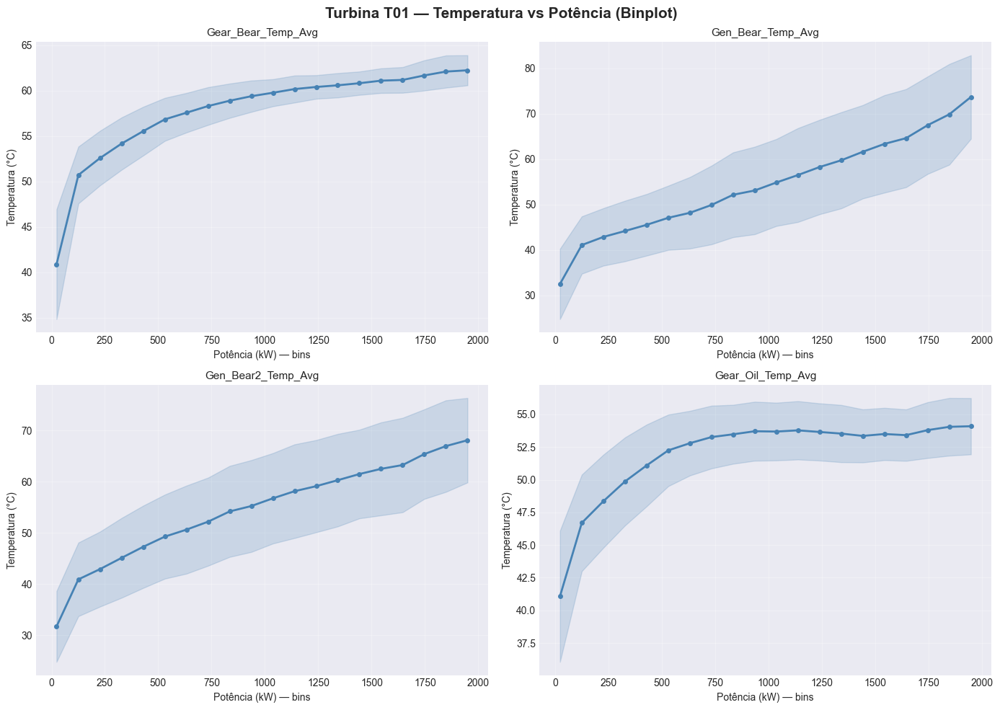

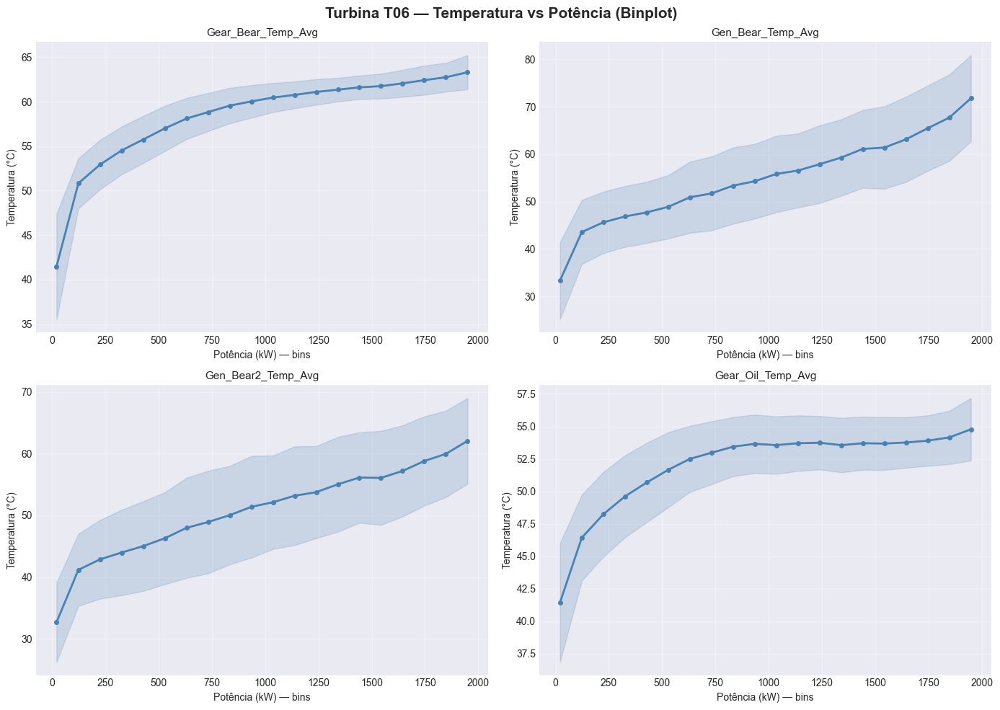

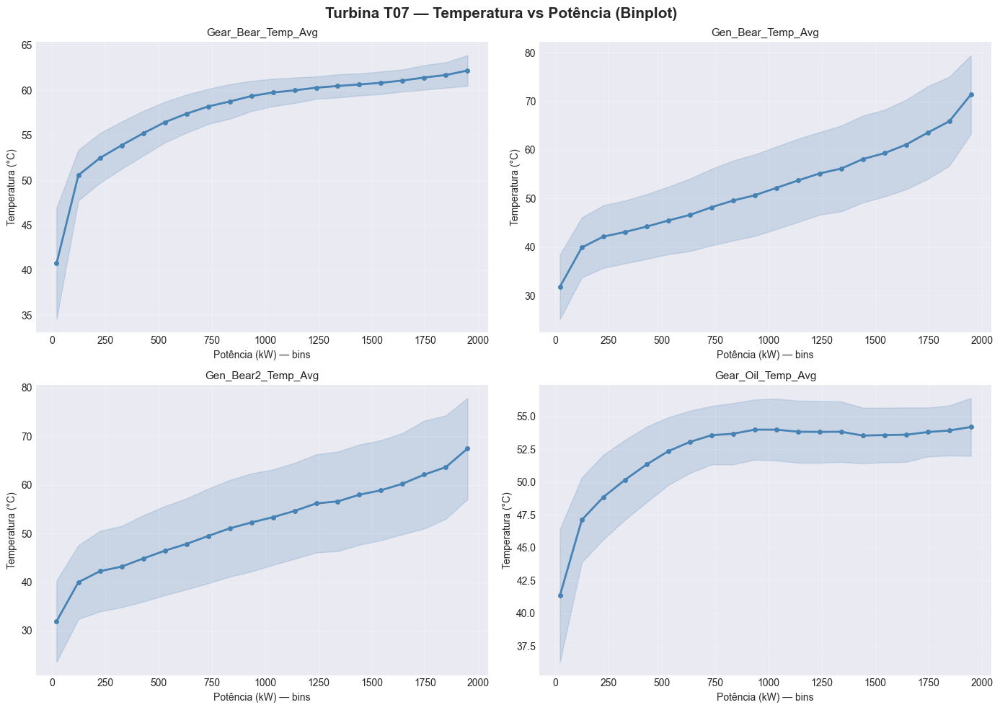

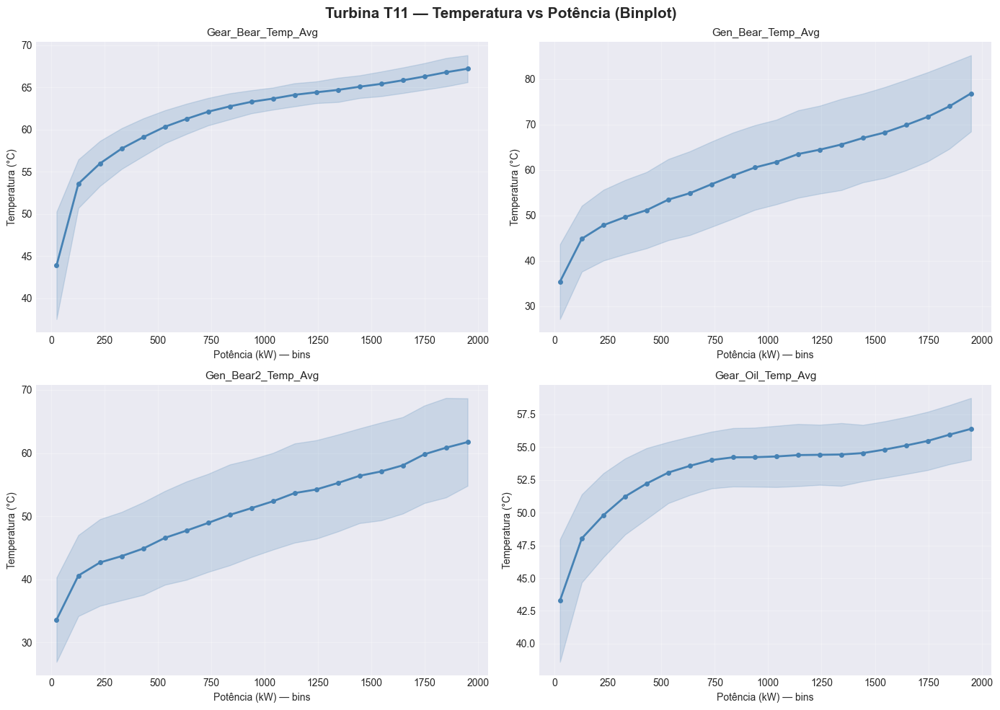

In [9]:
# Célula 4F — Temperatura vs Potência - Binplot (por Turbina)

temp_cols = ['Gear_Bear_Temp_Avg', 'Gen_Bear_Temp_Avg', 'Gen_Bear2_Temp_Avg', 'Gear_Oil_Temp_Avg']

for tid in TURBINES:
    df_t = turbines[tid]
    clean = df_t[df_t['outlier_flag'] == 0].copy()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Turbina {tid} — Temperatura vs Potência (Binplot)', fontsize=15, fontweight='bold')
    axes = axes.flatten()

    for i, col in enumerate(temp_cols):
        ax = axes[i]

        # Dividir a potência em 20 bins
        clean['pwr_bin'] = pd.cut(clean['Grd_Prod_Pwr_Avg'], bins=20)
        grouped = clean.groupby('pwr_bin', observed=True)[col]
        means = grouped.mean()
        stds = grouped.std()

        # Centros dos bins para o eixo X
        bin_centers = [interval.mid for interval in means.index]

        ax.plot(bin_centers, means.values, 'o-', color='steelblue', linewidth=2, markersize=4)
        ax.fill_between(bin_centers,
                        means.values - stds.values,
                        means.values + stds.values,
                        alpha=0.2, color='steelblue')

        ax.set_title(col, fontsize=11)
        ax.set_xlabel('Potência (kW) — bins')
        ax.set_ylabel('Temperatura (°C)')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Para cada turbina, a potência é dividida em 20 bins e calcula-se a média e desvio padrão de cada variável de temperatura (rolamentos da caixa, rolamentos do gerador, óleo da caixa) em cada bin. A linha central mostra a tendência e a faixa sombreada representa ±1 desvio padrão.

**Informações obtidas:**
- **Perfil térmico normal:** A curva temperatura × potência define o "perfil térmico de referência" de cada componente. Componentes rotativos aquecem com a carga, então espera-se uma curva crescente — rolamentos do gerador e óleo da caixa multiplicadora aumentam de temperatura conforme a potência sobe.
- **Detecção de anomalias:** Desvios futuros desse perfil de referência (temperatura anormalmente alta para uma dada potência) são indicadores precoces de degradação — por exemplo, rolamento com lubrificação insuficiente ou entupimento de filtro de óleo.
- **Dispersão (faixa sombreada):** Faixas largas indicam que a temperatura flutua bastante para o mesmo nível de potência, possivelmente por variação da temperatura ambiente, velocidade do vento ou ciclo térmico.
- **Comparação entre turbinas:** Perfis térmicos muito diferentes entre turbinas do mesmo modelo sugerem diferenças de desgaste, condição de manutenção ou ambiente operacional.

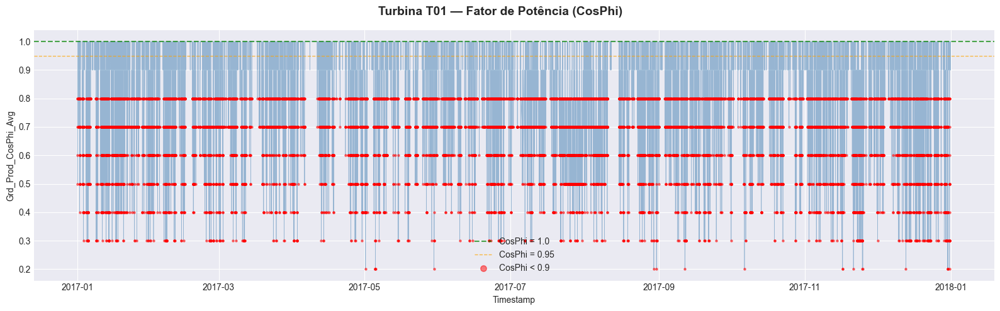

  T01: 30.1% dos registros com CosPhi < 0.9



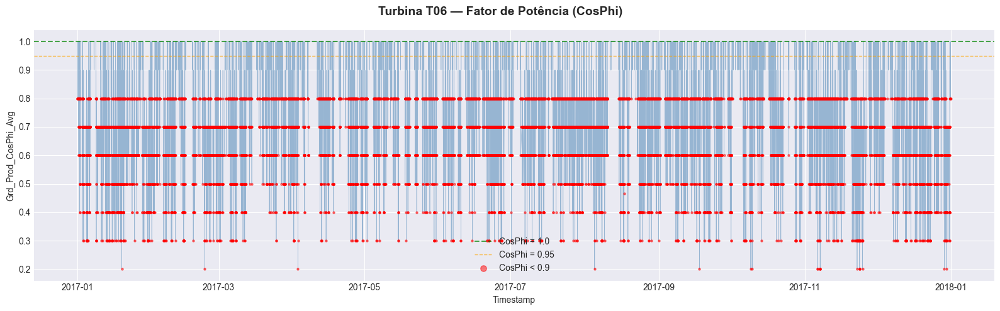

  T06: 46.3% dos registros com CosPhi < 0.9



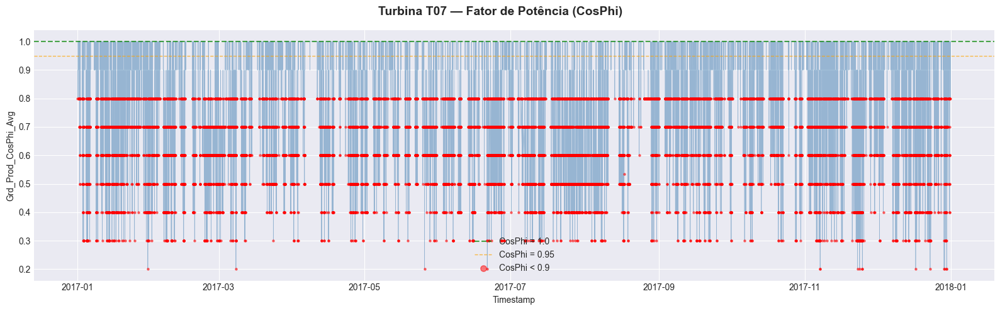

  T07: 37.2% dos registros com CosPhi < 0.9



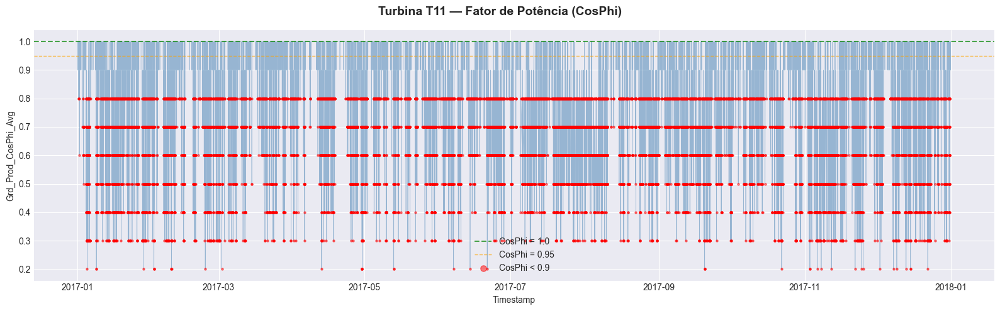

  T11: 37.4% dos registros com CosPhi < 0.9



In [10]:
# Célula 4G — Fator de Potência ao Longo do Tempo (por Turbina)

for tid in TURBINES:
    df_t = turbines[tid].sort_values('Timestamp')

    fig, ax = plt.subplots(figsize=(16, 5))
    fig.suptitle(f'Turbina {tid} — Fator de Potência (CosPhi)', fontsize=14, fontweight='bold')

    ax.plot(df_t['Timestamp'], df_t['Grd_Prod_CosPhi_Avg'],
            alpha=0.5, linewidth=0.5, color='steelblue')

    # Linhas de referência
    ax.axhline(y=1.0, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='CosPhi = 1.0')
    ax.axhline(y=0.95, color='orange', linestyle='--', linewidth=1.0, alpha=0.7, label='CosPhi = 0.95')

    # Destacar pontos abaixo de 0.9
    low_cosphi = df_t[df_t['Grd_Prod_CosPhi_Avg'] < 0.9]
    ax.scatter(low_cosphi['Timestamp'], low_cosphi['Grd_Prod_CosPhi_Avg'],
               s=5, c='red', alpha=0.5, zorder=3, label='CosPhi < 0.9')

    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Grd_Prod_CosPhi_Avg')
    ax.legend(fontsize=10, markerscale=3)
    plt.tight_layout()
    plt.show()

    pct_low = len(low_cosphi) / max(len(df_t), 1) * 100
    print(f"  {tid}: {pct_low:.1f}% dos registros com CosPhi < 0.9\n")

A série temporal do fator de potência (`Grd_Prod_CosPhi_Avg`) mostra a qualidade da potência entregue à rede por cada turbina. CosPhi = 1.0 significa potência puramente ativa (ideal); valores menores indicam presença de potência reativa.

**Informações obtidas:**
- **Qualidade da energia:** Um CosPhi consistentemente próximo de 1.0 indica que a turbina entrega energia de alta qualidade à rede. O operador da rede tipicamente exige CosPhi > 0.95 como requisito contratual.
- **Pontos com CosPhi < 0.9 (vermelho):** Indicam momentos de operação com excesso de potência reativa — isso pode ocorrer durante transitórios de conexão/desconexão da rede, operação a baixa carga, ou problemas no conversor de frequência.
- **Percentual de registros baixos:** A porcentagem impressa quantifica a frequência dessas ocorrências. Se elevada, pode indicar necessidade de ajuste no sistema de compensação reativa da turbina.
- **Padrões temporais:** Clustering de pontos vermelhos em períodos específicos pode correlacionar-se com eventos da rede (subtensão, sobretensão) ou condições operacionais particulares (ventos muito baixos ou muito altos).

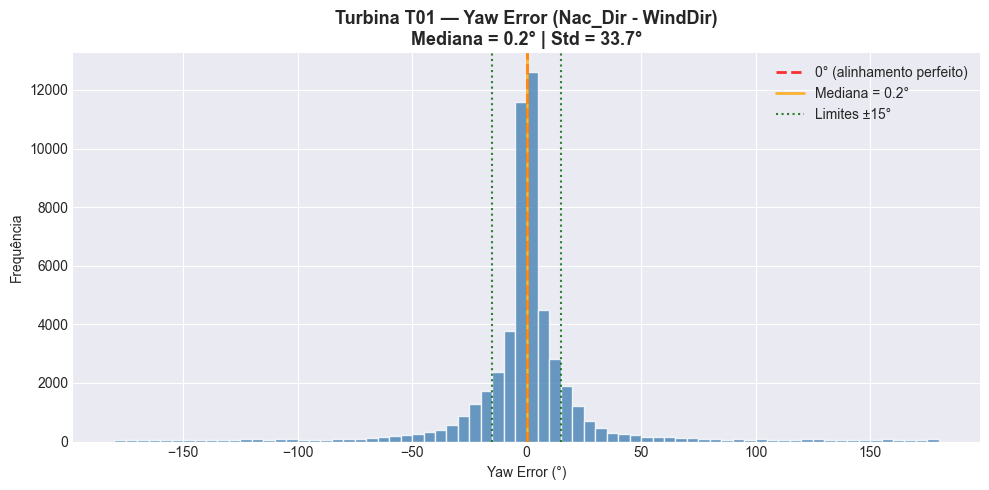

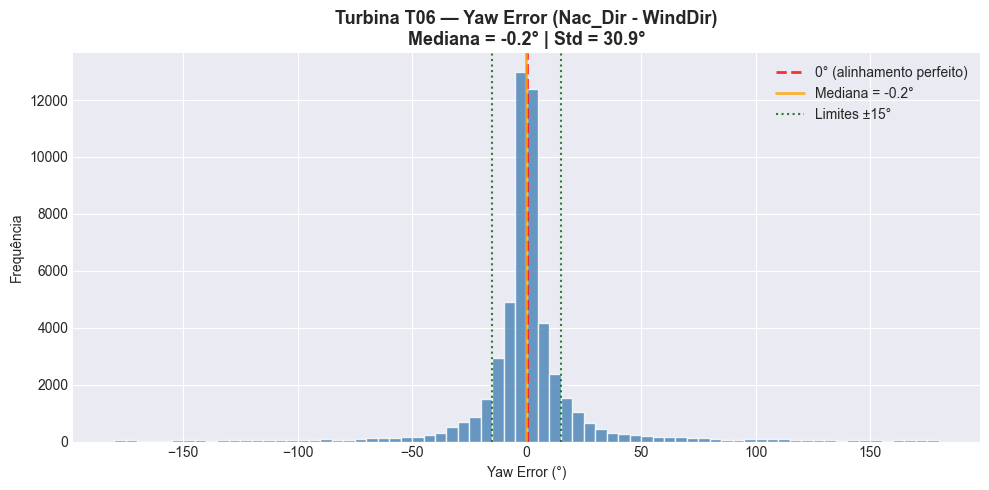

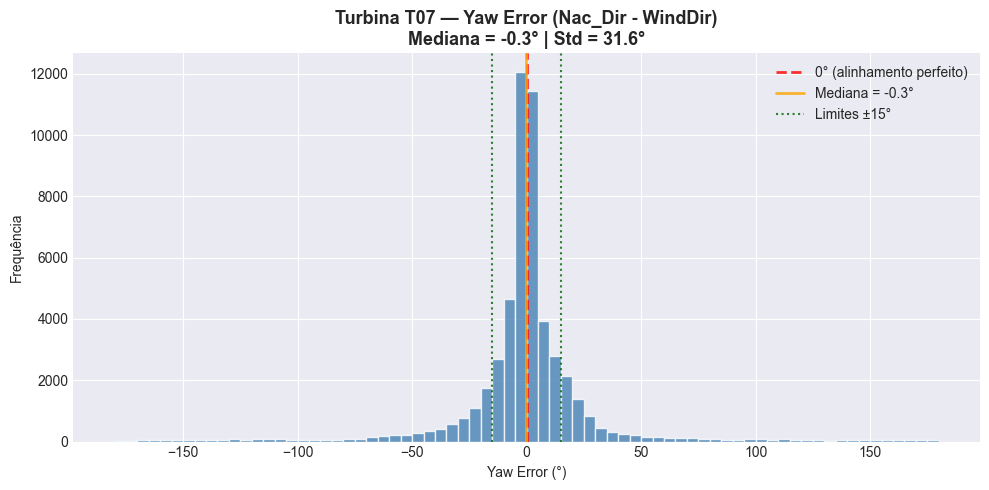

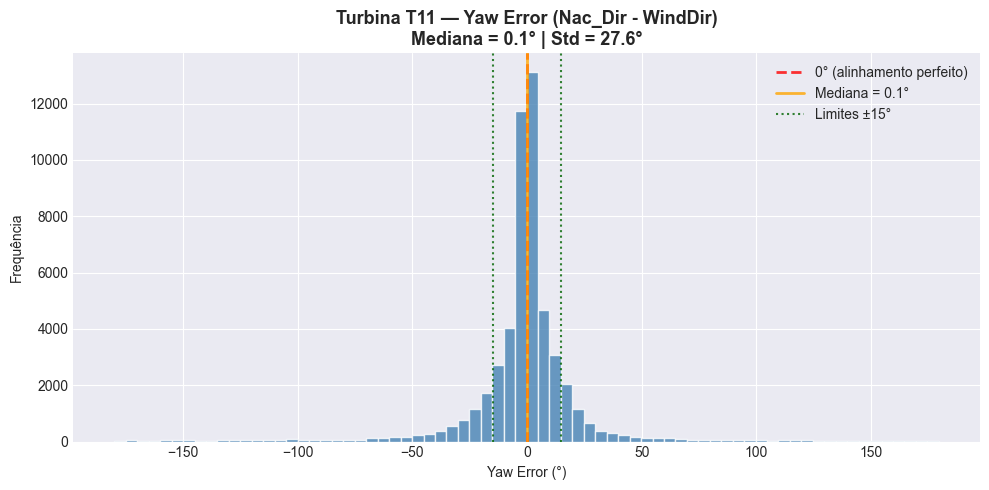

In [11]:
# Célula 4H — Yaw Error - Histograma (por Turbina)

for tid in TURBINES:
    _ = plot_yaw_histogram(turbines[tid], tid)

O histograma mostra a distribuição do erro de yaw (diferença circular entre a direção da nacele e a direção do vento) para cada turbina. A linha vermelha marca o alinhamento perfeito (0°) e a linha laranja a mediana do erro.

**Informações obtidas:**
- **Mediana do yaw error:** Valores diferentes de 0° indicam um viés sistemático (bias) no sistema de yaw da turbina — a nacele tende a ficar consistentemente desalinhada em relação ao vento. Bias > 5° é significativo e merece investigação.
- **Desvio padrão:** Alta dispersão (std > 15–20°) sugere que o sistema de yaw é lento para responder a mudanças de direção do vento, ou que há alta turbulência direcional no site.
- **Impacto na geração:** O yaw error reduz a potência capturada pelo fator cos³(θ) — um erro de 10° causa ~4.5% de perda, e 20° causa ~18%. Turbinas com distribuição mais larga perdem mais energia.
- **Comparação entre turbinas:** Diferenças no perfil de yaw error entre turbinas podem indicar calibração inadequada de sensores de direção, problemas nos motores de yaw ou efeito da posição da turbina no layout (turbulência de esteira).
- **Ação corretiva:** Se o viés é consistente, pode ser corrigido por recalibração do sensor de vento ou ajuste no offset de yaw do controlador.

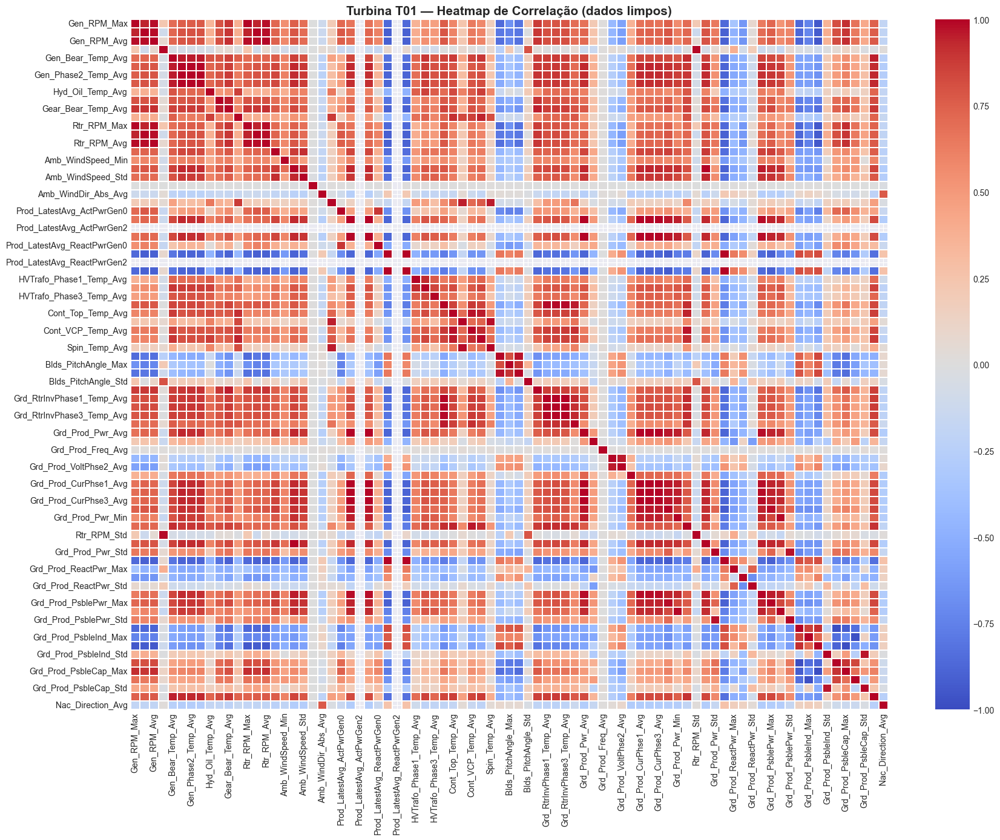

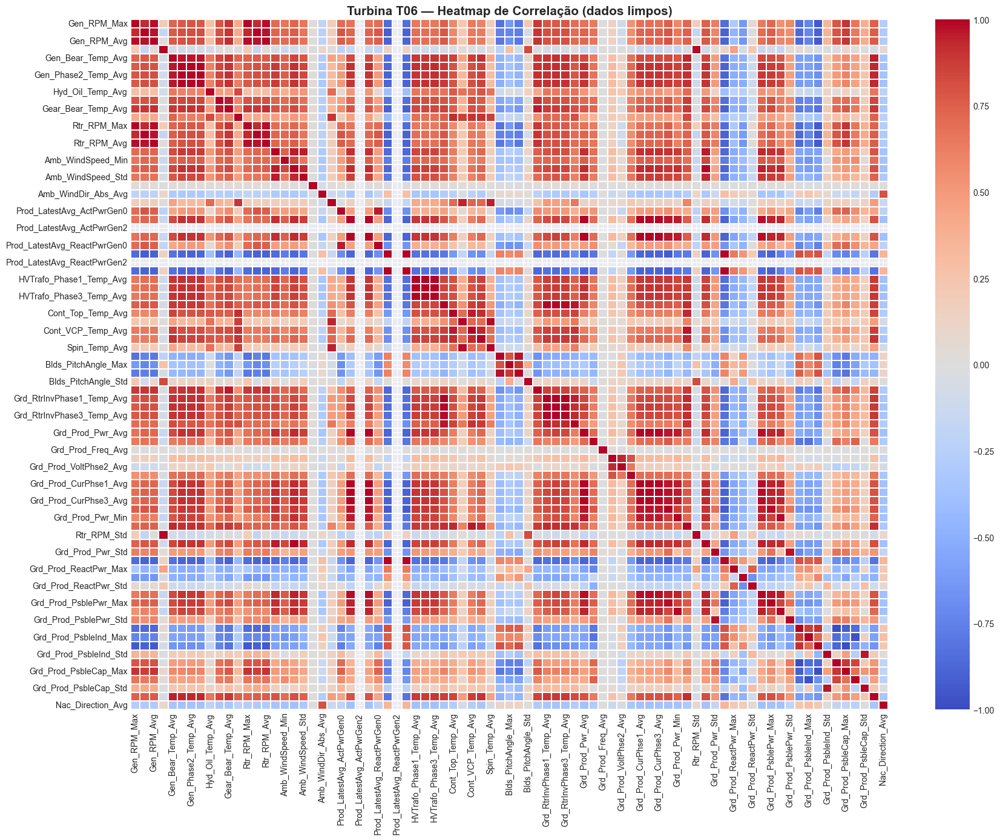

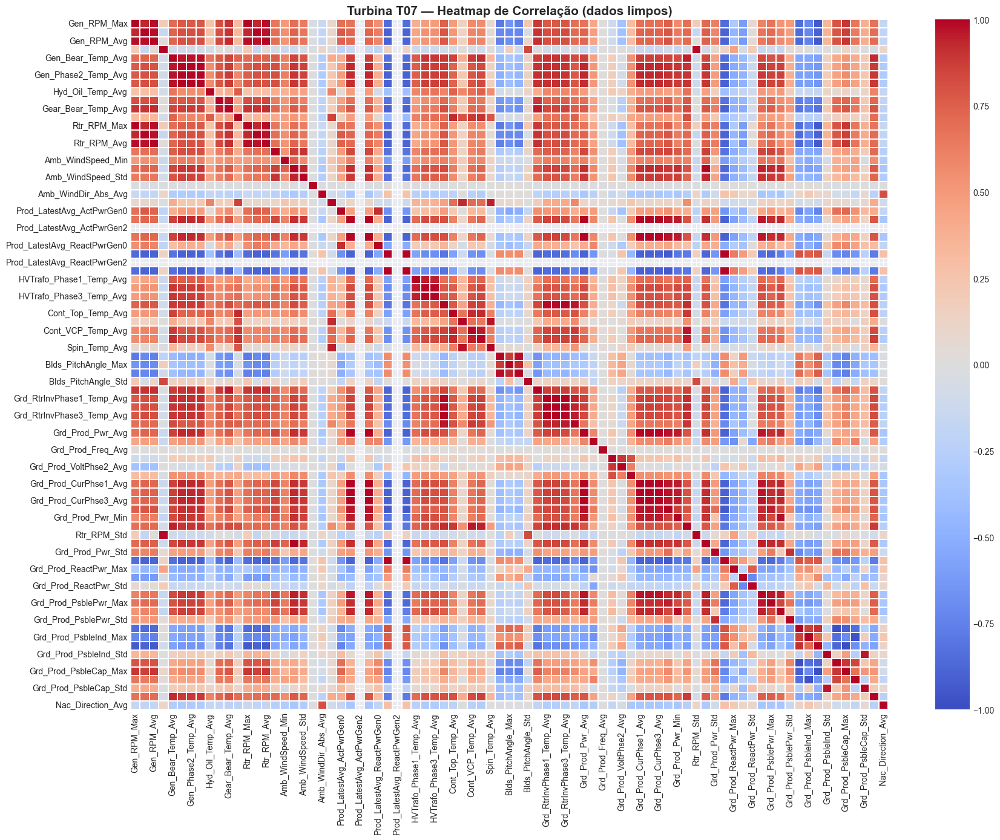

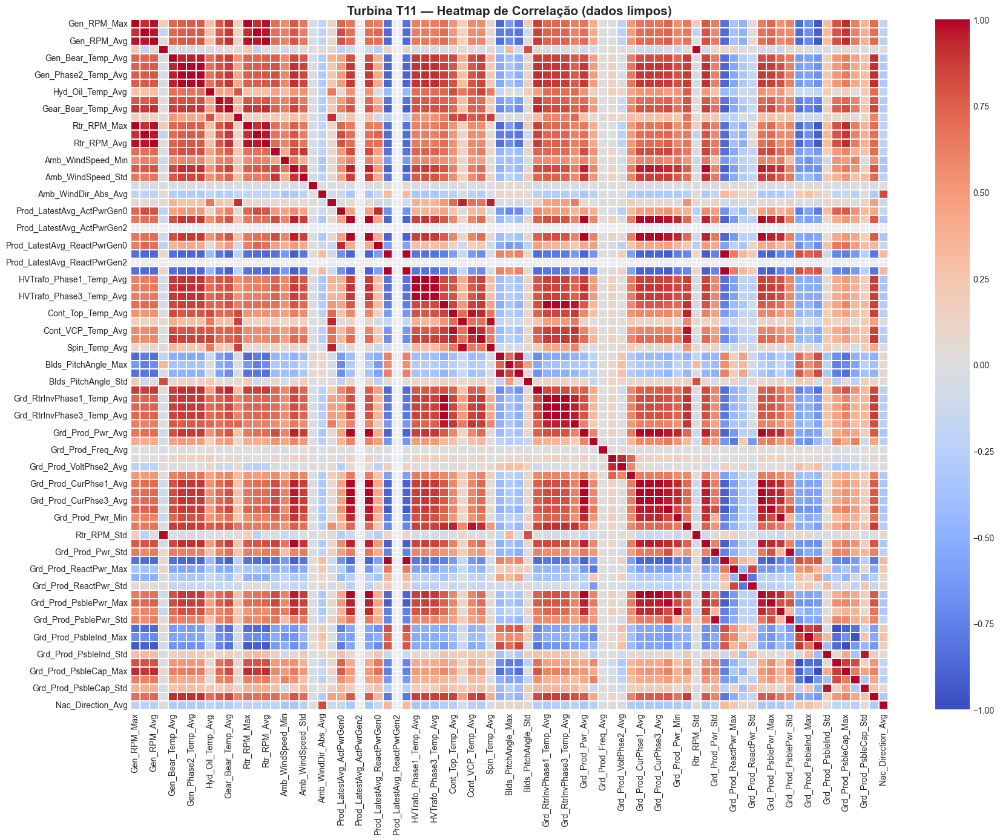

In [12]:
# Célula 4I — Heatmap de Correlação (por Turbina)

for tid in TURBINES:
    df_t = turbines[tid]
    clean = df_t[df_t['outlier_flag'] == 0]

    # Selecionar colunas numéricas, excluir outlier_flag, Failure_Component, Failure_Remarks
    num_cols = clean.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in ['outlier_flag', 'Failure_Component', 'Failure_Remarks']]

    corr_matrix = clean[num_cols].corr()

    fig, ax = plt.subplots(figsize=(18, 14))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
                fmt='.2f', linewidths=0.3, ax=ax, vmin=-1, vmax=1,
                square=False)
    ax.set_title(f'Turbina {tid} — Heatmap de Correlação (dados limpos)',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

Para cada turbina, é gerado um heatmap da matriz de correlação de Pearson entre todas as variáveis numéricas dos dados limpos (sem outliers). Isso permite analisar as interdependências entre os sinais SCADA.

**Informações obtidas:**
- **Correlações dominantes:** Variáveis como velocidade do vento, potência e RPM devem apresentar correlação forte e positiva — confirmando o comportamento físico esperado da turbina.
- **Temperaturas e carga:** Correlações entre temperaturas de componentes (rolamentos, óleo de caixa) e potência/RPM revelam como o aquecimento escala com a carga operacional.
- **Anomalias entre turbinas:** Se uma turbina apresenta padrão de correlação diferente das outras (ex: correlação fraca entre vento e potência), pode indicar problema operacional, curtailment ou falha no sensor.
- **Multicolinearidade:** Identificar pares de variáveis altamente correlacionadas (r > 0.9) é útil para evitar redundância em modelos preditivos de falha ou de geração.

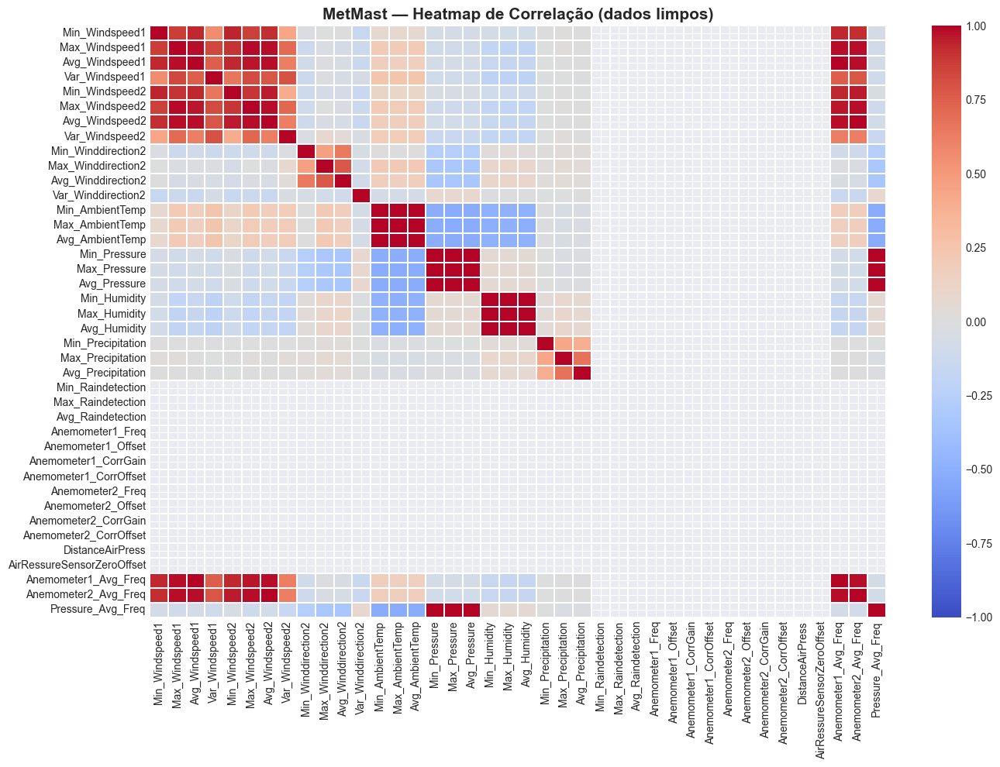

In [13]:
# Célula 13 — Heatmap do MetMast

# Selecionar colunas numéricas, excluir outlier_flag
metmast_clean = df_metmast[df_metmast['outlier_flag'] == 0]
num_cols_mm = metmast_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols_mm = [c for c in num_cols_mm if c != 'outlier_flag']

corr_mm = metmast_clean[num_cols_mm].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_mm, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax, vmin=-1, vmax=1, square=False)
ax.set_title('MetMast — Heatmap de Correlação (dados limpos)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Heatmap da matriz de correlação de Pearson entre todas as variáveis numéricas dos dados limpos (sem outliers) do MetMast (torre meteorológica onsite).

**Informações obtidas:**
- **Redundância entre sensores:** Correlações muito altas (r > 0.95) entre variáveis como `Avg_Windspeed1` e `Avg_Windspeed2` confirmam consistência entre anemômetros redundantes na mesma torre.
- **Relações atmosféricas:** Permite verificar relações físicas esperadas — ex: temperatura e pressão (lei dos gases), umidade e ponto de orvalho, velocidade e rajadas (windgusts correlacionados com windspeed).
- **Seleção de features:** Identifica quais variáveis meteorológicas carregam informação independente versus redundante, auxiliando na escolha de preditores para modelos de previsão de geração.
- **Comparação com heatmap SCADA:** Confrontando os dois heatmaps, é possível validar se os sensores da torre meteorológica e os da nacele medem fenômenos consistentes.

In [14]:
# Célula 14 — Join dos Datasets por Timestamp

# Verificar granularidade temporal
print("Granularidade SCADA:")
ts_scada = df_all['Timestamp'].sort_values().diff().dropna()
print(f"  Intervalo mediano: {ts_scada.median()}")
print(f"  Intervalo mais comum: {ts_scada.mode().iloc[0]}")

print("\nGranularidade MetMast:")
ts_mm = df_metmast['Timestamp'].sort_values().diff().dropna()
print(f"  Intervalo mediano: {ts_mm.median()}")
print(f"  Intervalo mais comum: {ts_mm.mode().iloc[0]}")

# Resample do MetMast para 10 minutos (se necessário) e merge
df_metmast_resampled = df_metmast.set_index('Timestamp').resample('10min').mean(numeric_only=True).reset_index()

# Merge inner por Timestamp
df_merged = pd.merge(df_all, df_metmast_resampled, on='Timestamp', how='inner',
                     suffixes=('_scada', '_metmast'))

print(f"\nShapes:")
print(f"  df_all: {df_all.shape}")
print(f"  df_metmast: {df_metmast.shape}")
print(f"  df_metmast_resampled: {df_metmast_resampled.shape}")
print(f"  df_merged: {df_merged.shape}")
df_merged.head()

Granularidade SCADA:
  Intervalo mediano: 0 days 00:00:00
  Intervalo mais comum: 0 days 00:00:00

Granularidade MetMast:
  Intervalo mediano: 0 days 00:10:00
  Intervalo mais comum: 0 days 00:10:00



Shapes:
  df_all: (209236, 84)
  df_metmast: (34831, 42)
  df_metmast_resampled: (52560, 42)
  df_merged: (209236, 125)


,Turbine_ID,Timestamp,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,Gen_Phase3_Temp_Avg,...,Anemometer2_Freq,Anemometer2_Offset,Anemometer2_CorrGain,Anemometer2_CorrOffset,DistanceAirPress,AirRessureSensorZeroOffset,Anemometer1_Avg_Freq,Anemometer2_Avg_Freq,Pressure_Avg_Freq,outlier_flag_metmast
0,T06,2017-12-29 20:30:00+00:00,1344.0,265.3,647.1,476.4,43.0,56.0,57.0,57.0,...,0.0499,0.24,1.0,0.0,0.0,600.0,66.0,65.0,420.0,0.0
1,T06,2017-12-29 20:40:00+00:00,311.0,275.0,293.1,8.9,43.0,53.0,54.0,53.0,...,0.0499,0.24,1.0,0.0,0.0,600.0,78.0,77.0,420.0,0.0
2,T06,2017-12-29 21:10:00+00:00,1433.2,266.5,475.6,383.1,40.0,48.0,49.0,49.0,...,0.0499,0.24,1.0,0.0,0.0,600.0,78.0,77.0,420.0,0.0
3,T06,2017-12-29 21:20:00+00:00,1272.4,988.6,1222.7,65.1,38.0,48.0,49.0,49.0,...,0.0499,0.24,1.0,0.0,0.0,600.0,64.0,63.0,420.0,0.0
4,T06,2017-12-29 21:50:00+00:00,1268.4,1051.9,1200.5,65.3,36.0,46.0,47.0,47.0,...,0.0499,0.24,1.0,0.0,0.0,600.0,75.0,74.0,420.0,0.0


Esta célula verifica a granularidade temporal de ambos os datasets (SCADA das turbinas e MetMast), reamostra o MetMast para intervalos de 10 minutos e realiza o merge inner por Timestamp, criando o dataset consolidado `df_merged`.

**Informações obtidas:**
- **Granularidade temporal:** O intervalo mediano e modal confirmam se os dados SCADA e MetMast estão na mesma resolução (tipicamente 10 min). Discrepâncias indicam necessidade de reamostragem.
- **Perda de dados no merge:** Comparando os shapes antes e depois do merge, identifica-se quantos registros foram perdidos por não terem correspondência temporal — isso pode indicar períodos em que o MetMast ou o SCADA estavam offline.
- **Utilidade:** O dataset `df_merged` permite análises cruzadas (ex: comparar vento medido na nacele vs torre meteorológica, correlacionar variáveis atmosféricas com performance) que não seriam possíveis com os datasets separados.

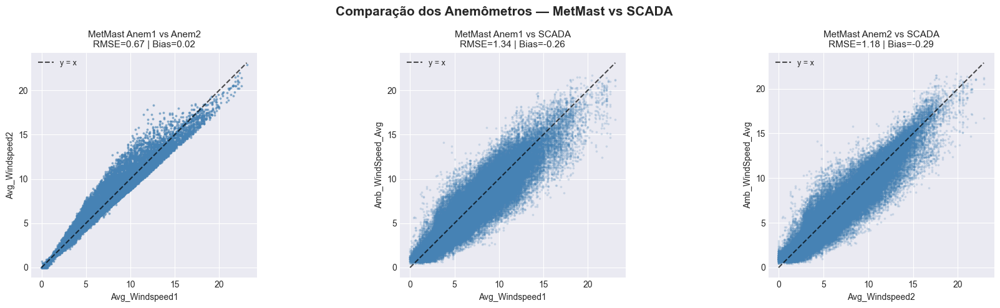

In [15]:
# Célula 15 — Comparação dos Anemômetros

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparação dos Anemômetros — MetMast vs SCADA', fontsize=15, fontweight='bold')

comparisons = [
    ('Avg_Windspeed1', 'Avg_Windspeed2', 'MetMast Anem1 vs Anem2'),
    ('Avg_Windspeed1', 'Amb_WindSpeed_Avg', 'MetMast Anem1 vs SCADA'),
    ('Avg_Windspeed2', 'Amb_WindSpeed_Avg', 'MetMast Anem2 vs SCADA'),
]

for ax, (col_x, col_y, title) in zip(axes, comparisons):
    mask = df_merged[[col_x, col_y]].dropna()
    x, y = mask[col_x], mask[col_y]

    ax.scatter(x, y, alpha=0.15, s=3, c='steelblue')

    # Linha de identidade y=x
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.7, label='y = x')

    # RMSE e Bias
    rmse = np.sqrt(np.mean((x - y) ** 2))
    bias = np.mean(y - x)

    ax.set_title(f'{title}\nRMSE={rmse:.2f} | Bias={bias:.2f}', fontsize=11)
    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)
    ax.legend(fontsize=9)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

Três scatter plots comparam as medições de velocidade do vento entre os dois anemômetros do MetMast (`Avg_Windspeed1`, `Avg_Windspeed2`) e o anemômetro da nacele SCADA (`Amb_WindSpeed_Avg`). A linha tracejada y=x representa concordância perfeita. RMSE e Bias quantificam as discrepâncias.

**Informações obtidas:**
- **Anem1 vs Anem2 (MetMast):** Esses dois sensores estão na mesma torre, tipicamente a alturas ou posições ligeiramente diferentes. Alta concordância (RMSE baixo, Bias ~0) indica que ambos estão calibrados e funcionando corretamente. Discrepância sugere necessidade de recalibração ou efeito de sombreamento pela torre.
- **MetMast vs SCADA:** O anemômetro da nacele sofre interferência do rotor (fator de indução axial) e da própria nacele, lendo velocidades sistematicamente diferentes do vento livre. O Bias quantifica essa diferença — valores positivos indicam que o SCADA superestima (ou o MetMast subestima).


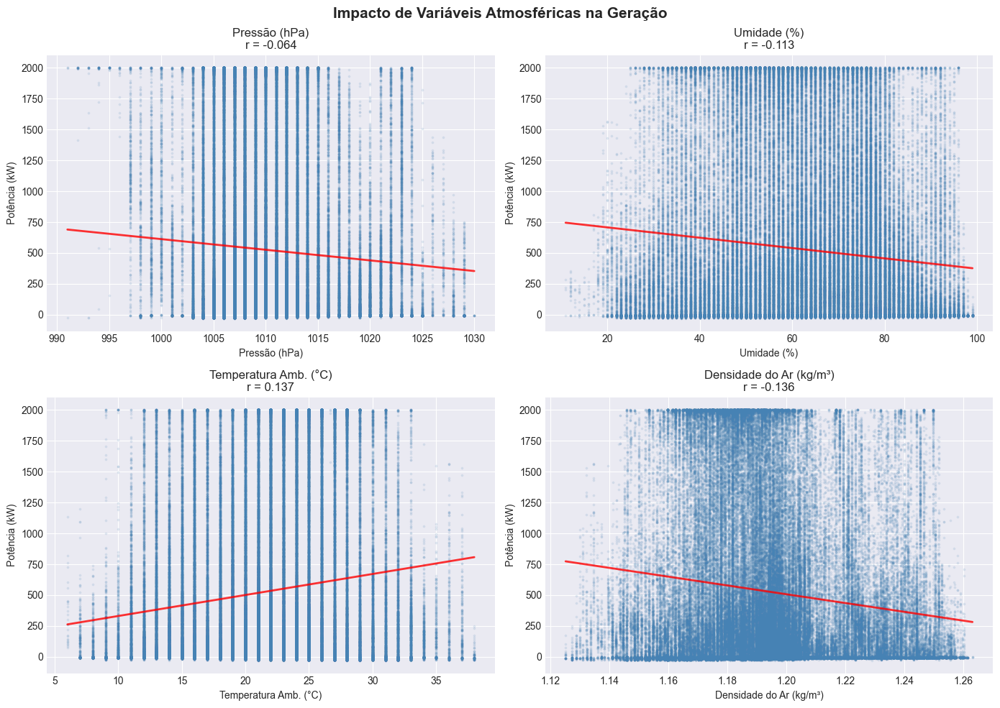

In [16]:
# Célula 16 — Impacto da Pressão, Umidade e Temperatura na Geração

# Calcular densidade do ar: rho = (P * 100) / (287.05 * (T + 273.15))
# P em hPa → Pa, T em °C → K
df_merged['rho'] = (df_merged['Avg_Pressure'] * 100) / (287.05 * (df_merged['Avg_AmbientTemp'] + 273.15))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Impacto de Variáveis Atmosféricas na Geração', fontsize=15, fontweight='bold')
axes = axes.flatten()

variables = [
    ('Avg_Pressure', 'Pressão (hPa)'),
    ('Avg_Humidity', 'Umidade (%)'),
    ('Avg_AmbientTemp', 'Temperatura Amb. (°C)'),
    ('rho', 'Densidade do Ar (kg/m³)'),
]

for ax, (col, label) in zip(axes, variables):
    mask = df_merged[[col, 'Grd_Prod_Pwr_Avg']].dropna()
    x, y = mask[col], mask['Grd_Prod_Pwr_Avg']

    ax.scatter(x, y, alpha=0.1, s=3, c='steelblue')

    # Linha de tendência
    if len(mask) > 10:
        coeffs = np.polyfit(x, y, 1)
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = np.polyval(coeffs, x_fit)
        ax.plot(x_fit, y_fit, 'r-', linewidth=2, alpha=0.8)

        # Correlação de Pearson
        corr_pearson = np.corrcoef(x, y)[0, 1]
        ax.set_title(f'{label}\nr = {corr_pearson:.3f}', fontsize=12)
    else:
        ax.set_title(label, fontsize=12)

    ax.set_xlabel(label)
    ax.set_ylabel('Potência (kW)')

plt.tight_layout()
plt.show()

Quatro scatter plots relacionam variáveis atmosféricas do MetMast (pressão, umidade, temperatura ambiente e densidade do ar calculada) com a potência gerada. Cada gráfico inclui uma linha de tendência linear e o coeficiente de correlação de Pearson (r).

**Informações obtidas:**
- **Densidade do ar (ρ):** A potência eólica é proporcional a ρ (P = ½ρAv³). Espera-se correlação positiva entre ρ e Power. Variações sazonais de temperatura e pressão alteram ρ e, consequentemente, a geração — o gráfico quantifica esse efeito.
- **Pressão atmosférica:** Maior pressão → maior ρ → maior potência disponível. Porém, o efeito é modesto (~1–3% de variação na geração para variações típicas de pressão).
- **Temperatura ambiente:** Relação tipicamente inversa (r negativo) — ar quente é menos denso, logo contém menos energia cinética para o mesmo vento. Esse efeito é mais relevante em sites com grandes amplitudes térmicas sazonais.
- **Umidade relativa:** O impacto na densidade do ar é pequeno (ar úmido é ~0.5% menos denso que ar seco à mesma T e P), mas pode correlacionar-se com padrões meteorológicos específicos que afetam o vento.
- **Utilidade prática:** Esses fatores são usados em correções de curva de potência para condições padrão e em modelos de previsão de produção energética.

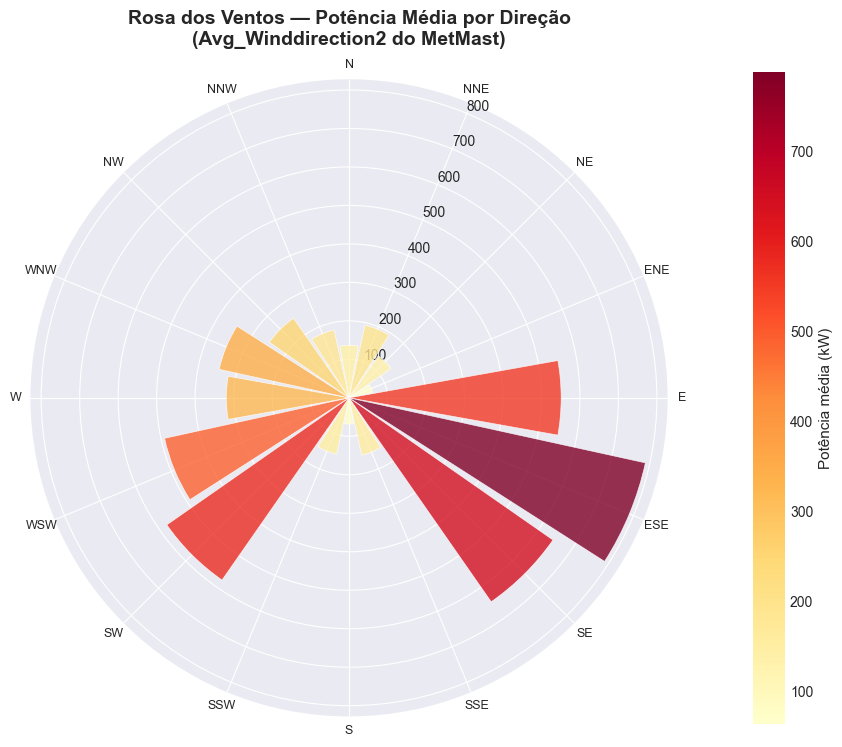

In [17]:
# Célula 18 — Rosa dos Ventos com Potência Média

# 16 setores de 22.5°
n_sectors = 16
sector_width = 360 / n_sectors  # 22.5°

dir_labels = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
              'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']

# Classificar cada observação no setor correto
df_merged['wind_sector'] = df_merged['Avg_Winddirection2'].apply(
    lambda x: int(((x + sector_width / 2) % 360) // sector_width) if pd.notna(x) else np.nan
)

# Calcular potência média por setor
pwr_by_sector = df_merged.groupby('wind_sector')['Grd_Prod_Pwr_Avg'].mean()
pwr_by_sector = pwr_by_sector.reindex(range(n_sectors), fill_value=0)

# Ângulos centrais em radianos
angles = np.radians(np.arange(0, 360, sector_width))
bar_width = np.radians(sector_width) * 0.9

# Colorbar por intensidade de potência
norm = plt.Normalize(vmin=pwr_by_sector.values.min(), vmax=pwr_by_sector.values.max())
colors = plt.cm.YlOrRd(norm(pwr_by_sector.values))

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': 'polar'})

bars = ax.bar(angles, pwr_by_sector.values, width=bar_width, alpha=0.8,
              color=colors, edgecolor='white', linewidth=0.5)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, sector_width), dir_labels, fontsize=9)
ax.set_title('Rosa dos Ventos — Potência Média por Direção\n(Avg_Winddirection2 do MetMast)',
             fontsize=14, fontweight='bold', pad=25)

# Colorbar
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.75, pad=0.1)
cbar.set_label('Potência média (kW)', fontsize=11)

plt.tight_layout()
plt.show()

A rosa dos ventos polar divide a direção do vento (via `Avg_Winddirection2` do MetMast) em 16 setores de 22,5° e exibe a potência média gerada pelas turbinas para cada setor direcional. A cor das barras codifica a intensidade da potência.

**Informações obtidas:**
- **Direções de maior geração:** Os setores com barras mais altas e cores mais quentes indicam de onde sopram os ventos que mais contribuem para a produção de energia. Isso combina frequência e intensidade do vento naquela direção.
- **Regime eólico do site:** Se a rosa é concentrada em poucos setores, o site possui um regime eólico bem definido (favorável ao micrositing). Se é dispersa, há maior complexidade no posicionamento das turbinas.
- **Wake effect (efeito esteira):** Sabendo a direção predominante de geração, é possível avaliar se turbinas a sotavento sofrem redução de produção por esteira aerodinâmica das turbinas a barlavento.
- **Validação cruzada:** Comparar a rosa de potência com a rosa de frequência/velocidade (se disponível) permite verificar consistência — setores com vento forte mas baixa potência podem indicar curtailment direcional ou problemas de yaw.

DBSCAN MULTIDIMENSIONAL (PCA) — POR TURBINA

——————————————————————————————————————————————————
Processando: T01
  Colunas numéricas válidas: 81
  PCA: 81D → 15D (95.1% variância)
  DBSCAN: 1 clusters | 0 pontos de ruído (0.0%)

——————————————————————————————————————————————————
Processando: T06
  Colunas numéricas válidas: 81
  PCA: 81D → 14D (95.5% variância)
  DBSCAN: 1 clusters | 3 pontos de ruído (0.0%)

——————————————————————————————————————————————————
Processando: T07
  Colunas numéricas válidas: 81
  PCA: 81D → 16D (95.3% variância)
  DBSCAN: 1 clusters | 0 pontos de ruído (0.0%)

——————————————————————————————————————————————————
Processando: T11
  Colunas numéricas válidas: 81
  PCA: 81D → 15D (95.5% variância)
  DBSCAN: 1 clusters | 2 pontos de ruído (0.0%)


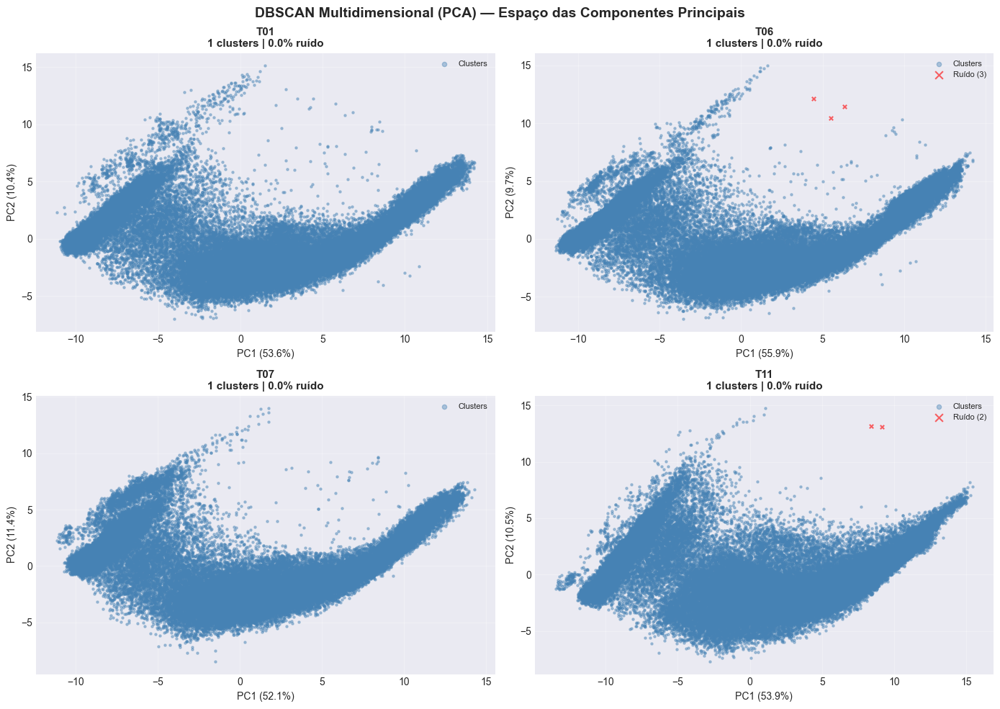


COMPARAÇÃO: DBSCAN-PCA vs OUTLIER_FLAG EXISTENTE


MemoryError: 

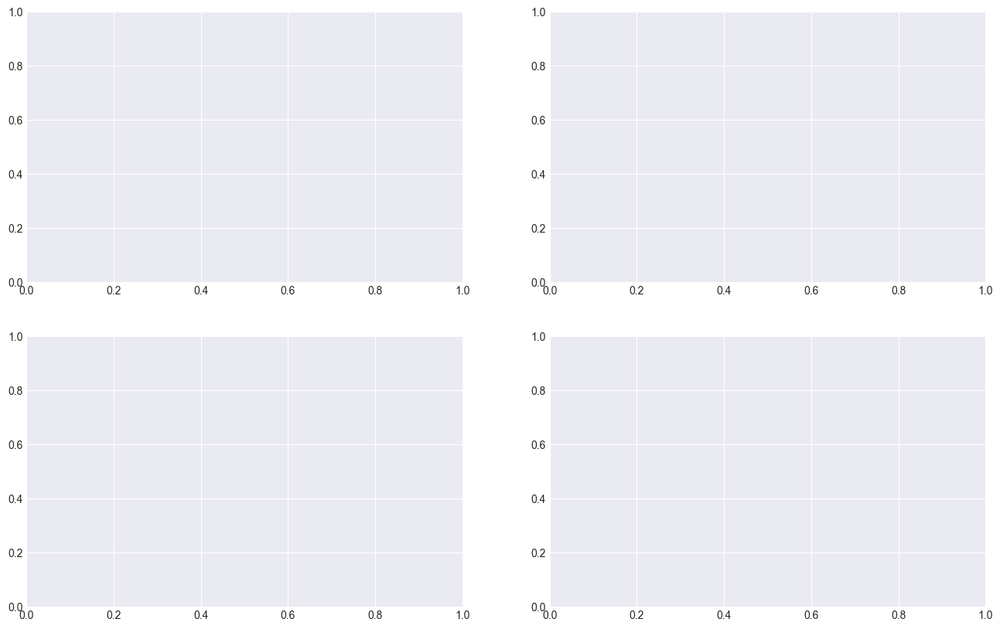

In [19]:
# DBSCAN Multidimensional com PCA — abordagem idêntica à do definitive_analysis
# Usa TODAS as variáveis numéricas, PCA para redução de dimensionalidade, DBSCAN no espaço reduzido

from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.cluster import DBSCAN

print("=" * 70)
print("DBSCAN MULTIDIMENSIONAL (PCA) — POR TURBINA")
print("=" * 70)

n_turbs = len(TURBINES)
fig_pca, axes_pca = plt.subplots(2, (n_turbs + 1) // 2, figsize=(14, 10))
axes_pca = axes_pca.flatten()

for idx, tid in enumerate(TURBINES):
    df_t = turbines[tid].copy()
    print(f"\n{'—'*50}")
    print(f"Processando: {tid}")

    # Selecionar colunas numéricas (excluir outlier_flag e colunas não-informativas)
    colunas_num = df_t.select_dtypes(include=[np.number]).columns.tolist()
    excluir = ['outlier_flag']
    colunas_num = [c for c in colunas_num if c not in excluir]

    # Remover colunas 100% vazias
    colunas_validas = [c for c in colunas_num if df_t[c].notna().sum() > 0]
    print(f"  Colunas numéricas válidas: {len(colunas_validas)}")

    dados = df_t[colunas_validas].copy()

    # Preencher NaN temporariamente com KNN (apenas para clustering)
    imputer = KNNImputer(n_neighbors=3)
    dados_preenchidos = pd.DataFrame(
        imputer.fit_transform(dados), columns=colunas_validas, index=dados.index
    )

    # Normalizar
    scaler = StandardScaler()
    dados_norm = scaler.fit_transform(dados_preenchidos)

    # PCA: reter 95% da variância
    pca = PCA(n_components=0.95)
    dados_pca = pca.fit_transform(dados_norm)
    n_comp = dados_pca.shape[1]
    var_expl = pca.explained_variance_ratio_.sum() * 100
    print(f"  PCA: {len(colunas_validas)}D → {n_comp}D ({var_expl:.1f}% variância)")

    # DBSCAN no espaço PCA via função auxiliar reutilizável
    if dados_pca.shape[1] >= 2:
        pca_db_df = pd.DataFrame({'pc1': dados_pca[:, 0], 'pc2': dados_pca[:, 1]}, index=df_t.index)
        # Evita MemoryError do helper em conjuntos grandes
        if len(pca_db_df) > 30000:

            xy = pca_db_df[['pc1', 'pc2']].to_numpy(dtype=np.float32, copy=False)
            labels = DBSCAN(
            eps=2.0,
            min_samples=5,
            metric='euclidean',
            algorithm='ball_tree',
            n_jobs=-1
            ).fit_predict(xy)
            labels_series = pd.Series(labels, index=pca_db_df.index, name='cluster')
        else:
            labels_series = run_dbscan_analysis(
            pca_db_df, x_col='pc1', y_col='pc2', eps=2.0, min_samples=5
            )
        labels = labels_series.fillna(-1).astype(int).values
        pc1 = dados_pca[:, 0]
        pc2 = dados_pca[:, 1]
        pc2_var = pca.explained_variance_ratio_[1] * 100
    else:
        pca_db_df = pd.DataFrame({'pc1': dados_pca[:, 0], 'pc2': np.zeros(len(dados_pca))}, index=df_t.index)
        labels_series = run_dbscan_analysis(pca_db_df, x_col='pc1', y_col='pc2', eps=2.0, min_samples=5)
        labels = labels_series.fillna(-1).astype(int).values
        pc1 = dados_pca[:, 0]
        pc2 = np.zeros_like(pc1)
        pc2_var = 0.0

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    pct_noise = n_noise / len(labels) * 100
    print(f"  DBSCAN: {n_clusters} clusters | {n_noise} pontos de ruído ({pct_noise:.1f}%)")

    # === Subplot PCA: PC1 vs PC2 ===
    ax = axes_pca[idx]

    mask_noise = (labels == -1)
    mask_clean = np.logical_not(mask_noise)

    if mask_clean.sum() > 0:
        ax.scatter(pc1[mask_clean], pc2[mask_clean],
                   c='steelblue', s=5, alpha=0.4, label='Clusters')
    if mask_noise.sum() > 0:
        ax.scatter(pc1[mask_noise], pc2[mask_noise],
                   c='red', marker='x', s=15, alpha=0.6, label=f'Ruído ({n_noise})')

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pc2_var:.1f}%)')
    ax.set_title(f'{tid}\n{n_clusters} clusters | {pct_noise:.1f}% ruído',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)
    ax.grid(True, alpha=0.3)

# Remover subplots vazios
for j in range(n_turbs, len(axes_pca)):
    fig_pca.delaxes(axes_pca[j])

fig_pca.suptitle('DBSCAN Multidimensional (PCA) — Espaço das Componentes Principais',
                 fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# === Comparação: DBSCAN-PCA noise vs outlier_flag existente ===
print("\n" + "=" * 70)
print("COMPARAÇÃO: DBSCAN-PCA vs OUTLIER_FLAG EXISTENTE")
print("=" * 70)

fig_cmp, axes_cmp = plt.subplots(2, (n_turbs + 1) // 2, figsize=(16, 10))
axes_cmp = axes_cmp.flatten()

for idx, tid in enumerate(TURBINES):
    df_t = turbines[tid].copy()

    # Recalcular (reutilizando a lógica)
    colunas_num = df_t.select_dtypes(include=[np.number]).columns.tolist()
    colunas_num = [c for c in colunas_num if c not in ['outlier_flag']]
    colunas_validas = [c for c in colunas_num if df_t[c].notna().sum() > 0]
    dados = df_t[colunas_validas].copy()

    imputer = KNNImputer(n_neighbors=3)
    dados_preenchidos = pd.DataFrame(
        imputer.fit_transform(dados), columns=colunas_validas, index=dados.index
    )
    scaler = StandardScaler()
    dados_norm = scaler.fit_transform(dados_preenchidos)
    pca = PCA(n_components=0.95)
    dados_pca = pca.fit_transform(dados_norm)

    if dados_pca.shape[1] >= 2:
        pca_db_df = pd.DataFrame({'pc1': dados_pca[:, 0], 'pc2': dados_pca[:, 1]}, index=df_t.index)
    else:
        pca_db_df = pd.DataFrame({'pc1': dados_pca[:, 0], 'pc2': np.zeros(len(dados_pca))}, index=df_t.index)

    labels_series = run_dbscan_analysis(pca_db_df, x_col='pc1', y_col='pc2', eps=2.0, min_samples=5)
    labels = labels_series.fillna(-1).astype(int).values

    dbscan_noise = (labels == -1).astype(int)
    outlier_existing = df_t['outlier_flag'].values.astype(int)

    both = ((outlier_existing == 1) & (dbscan_noise == 1)).sum()
    only_flag = ((outlier_existing == 1) & (dbscan_noise == 0)).sum()
    only_dbscan = ((outlier_existing == 0) & (dbscan_noise == 1)).sum()
    neither = ((outlier_existing == 0) & (dbscan_noise == 0)).sum()

    cat = outlier_existing * 1 + dbscan_noise * 2
    colors_map = {0: 'steelblue', 1: 'orange', 2: 'red', 3: 'purple'}
    labels_map = {0: f'Normal ({neither})', 1: f'Só outlier_flag ({only_flag})',
                  2: f'Só DBSCAN-PCA ({only_dbscan})', 3: f'Ambos ({both})'}

    ax = axes_cmp[idx]
    for c_val in [0, 1, 2, 3]:
        subset_mask = (cat == c_val)
        if subset_mask.sum() > 0:
            ax.scatter(df_t.loc[subset_mask.astype(bool), 'Amb_WindSpeed_Avg'],
                       df_t.loc[subset_mask.astype(bool), 'Grd_Prod_Pwr_Avg'],
                       alpha=0.3, s=5, c=colors_map[c_val], label=labels_map[c_val])

    ax.set_title(f'{tid} — DBSCAN-PCA vs Outlier Flag', fontsize=11, fontweight='bold')
    ax.set_xlabel('Velocidade do Vento (m/s)')
    ax.set_ylabel('Potência (kW)')
    ax.legend(fontsize=7, markerscale=3, loc='upper left')
    ax.grid(True, alpha=0.3)

    print(f"\n  {tid}: Normal={neither} | Só outlier_flag={only_flag} | "
          f"Só DBSCAN-PCA={only_dbscan} | Ambos={both}")

for j in range(n_turbs, len(axes_cmp)):
    fig_cmp.delaxes(axes_cmp[j])

fig_cmp.suptitle('Comparação na Curva de Potência: DBSCAN-PCA vs Outlier Flag Original',
                 fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Informações obtidas:**
- **Clusters identificados:** Cada cluster representa uma região densa da curva de potência — tipicamente o cluster principal corresponde à operação normal da turbina. Clusters secundários podem representar modos operacionais distintos (ex: operação parcial, modo de teste, potência reduzida por noise-curtailment).
- **Pontos de ruído (noise):** Os pontos classificados como ruído pelo DBSCAN são observações que não se encaixam em nenhum agrupamento denso — candidatos a anomalias operacionais, falhas de sensor, curtailment atípico ou transitórios de partida/parada.
- **Comparação DBSCAN vs Outlier Flag:** O gráfico da direita compara os pontos de ruído do DBSCAN com os outliers previamente identificados (outlier_flag). Pontos detectados por **ambos os métodos** possuem alta confiança de serem anômalos. Pontos detectados **apenas pelo DBSCAN** podem revelar anomalias que o método anterior não capturou (e vice-versa).
- **Parâmetros:** `eps=0.15` (raio de vizinhança no espaço normalizado) e `min_samples=15` (mínimo de vizinhos para formar um cluster). Esses valores podem ser ajustados — eps menor = clusters mais compactos e mais ruído, eps maior = clusters mais abrangentes.
- **Utilidade prática:** O DBSCAN é uma ferramenta poderosa para detecção de anomalias não-supervisionada, útil como etapa de pré-processamento ou como sistema de alerta para condições operacionais atípicas.